### 1️⃣ Montar o drive 🚀


In [ ]:
import os
import pandas as pd
from abc import ABC, abstractmethod
import os
import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.ticker as mticker
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
### BIBLIOTECAS ###
import os
import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.ticker as mticker
import numpy as np



### 2️⃣ Edite a célula de código abaixo para definir os caminhos das pastas  
Se quiser, siga este padrão:  
📂 **`raw`** → Pasta onde estão os arquivos CSV originais.  
📂 **`processed`** → Pasta onde os arquivos ajustados serão salvos.  

> O mais importante é garantir que todos os arquivos CSV estejam em uma pasta e que a outra esteja pronta para salvar os arquivos processados.  
> Após isso, a célula imprimirá a lista de arquivos encontrados.  


In [ ]:
''' esta célula precisa ser ajustada com o caminho da pasta que
      estão todos os arquivos csv que vc quer mudar
'''

# Definir o caminho da pasta com os arquivos CSV

PASTA_ORIGEM = "/content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_curves/"
PASTA_DESTINO = "/content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_curves/19abr_curvestese"

# Criar a pasta de destino caso não exista
os.makedirs(PASTA_DESTINO, exist_ok=True)

# Listar os arquivos CSV na pasta
arquivos_csv = [f for f in os.listdir(PASTA_ORIGEM) if f.endswith(".csv")]
print("Arquivos encontrados:", arquivos_csv)
print(len(arquivos_csv), "arquivos encontrados")

Arquivos encontrados: ['C2 - DDT.csv', 'C3 - DDT.csv', 'C2 - PBSE.csv', 'C3 - PBSE.csv', 'C3 - APT.csv', 'C4 - APT.csv', 'C2 - ETA.csv', 'C3 - ETA.csv', 'C3 - BLANK1.csv', 'C4 - BLANK1.csv', 'C3 - BLANK2.csv', 'C4 - BLANK2.csv', 'C2 - BLANK3.csv', 'C3 - BLANK3.csv', 'C4 - BLANK3.csv', 'C3 - 100ato.csv', 'C4 - 185pico.csv', 'C3 - 100fento.csv', 'C4 - 370pico.csv', 'C3 - 100pico.csv', 'C4 - 556pico.csv', 'C3 - 185pico.csv', 'C4 - 741pico.csv', 'C3 - 370pico.csv', 'C3 - 556pico.csv', 'C3 - 741pico.csv', 'C4 - DDT.csv', 'C4 - ETA.csv', 'C4 - ETOH.csv', 'C4 - PBSE.csv', 'C5 - BARE.csv', 'C5 - ETOH.csv', 'C1 - 1ato.csv', 'C1 - 1fento.csv', 'C1 - 1pico.csv', 'C1 - 185pico.csv', 'C1 - 370pico.csv', 'C1 - 556pico.csv', 'C1 - 741pico.csv', 'C1 - APT.csv', 'C1 - BARE.csv', 'C1 - BLANK1.csv', 'C1 - BLANK2.csv', 'C1 - BLANK3.csv', 'C1 - DDT.csv', 'C1 - ETA.csv', 'C1 - ETOH.csv', 'C1 - PBSE.csv', 'C2 - 10ato.csv', 'C2 - 10fento.csv', 'C2 - 10pico.csv', 'C2 - 185pico.csv', 'C2 - 370pico.csv', 'C2 - 5

### 3️⃣ Execute a última célula e acompanhe os logs detalhados 🔥  
Assim, você verá todo o processo de ajuste dos arquivos.  


In [ ]:
class AjustadorCSV():
    def processar(self, caminho_arquivo):
        # Ler o CSV
        df = pd.read_csv(caminho_arquivo, sep=";", skiprows=16)  #Remove as 16 primeiras linhas, que é onde temos as informações da leitura do GFET

        nome_arquivo = caminho_arquivo.split("/")[-1]

        print("\n" + "="*60)
        print(f" 📂 Processando arquivo: {nome_arquivo}")
        print("="*60)

        print(f"🔍 Antes do ajuste: {df.shape[0]:,} linhas | {df.shape[1]} colunas")

        # Remover as últimas 501 linhas
        ###aqui escolhemos tratar apenas a ultima corrida (no meu caso o loop de medida foi 20 corridas em 500 passos)
        ### 500 + 1 linhas, pois tem-se uma linha no final do código, que retiraremos depois
        df = df.iloc[9574:10074, :]

        print("-"*60)
        print(f"✅ Após o ajuste: {df.shape[0]:,} linhas | {df.shape[1]} colunas")
        print("-"*60)

        # Criar o novo nome do arquivo
        novo_nome = nome_arquivo.replace(".csv", "_ajustado.csv")
        caminho_salvar = os.path.join(PASTA_DESTINO, novo_nome)

        # Salvar o novo CSV
        df.to_csv(caminho_salvar, index=False)

        print("📁 Arquivo ajustado salvo com sucesso! ✅")
        print(f"📍 Local: {caminho_salvar}")
        print("="*60)

        # Se quiser saber mais detalhes da tabela, descomente as linhas abaixo:
        # print("\n" + "+"*60)
        # print("📊 Informações sobre o DataFrame:")
        # print("+"*60)
        # df.info()

# Executar o processo para todos os arquivos encontrados
ajustador = AjustadorCSV()

for arquivo in arquivos_csv:
    caminho_completo = os.path.join(PASTA_ORIGEM, arquivo)
    ajustador.processar(caminho_completo)
print("Processo finalizado!")


 📂 Processando arquivo: C2 - DDT.csv
🔍 Antes do ajuste: 10,058 linhas | 21 colunas
------------------------------------------------------------
✅ Após o ajuste: 484 linhas | 21 colunas
------------------------------------------------------------
📁 Arquivo ajustado salvo com sucesso! ✅
📍 Local: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_curves/19abr_curvestese/C2 - DDT_ajustado.csv

 📂 Processando arquivo: C3 - DDT.csv
🔍 Antes do ajuste: 10,058 linhas | 21 colunas
------------------------------------------------------------
✅ Após o ajuste: 484 linhas | 21 colunas
------------------------------------------------------------
📁 Arquivo ajustado salvo com sucesso! ✅
📍 Local: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_curves/19abr_curvestese/C3 - DDT_ajustado.csv

 📂 Processando arquivo: C2 - PBSE.csv
🔍 Antes do ajuste: 10,058 linhas | 21 colunas
------------------------------------------------------------
✅ Após o ajuste: 484 linhas | 21 colunas
-------------------------------

In [ ]:
# Caminho onde estão os arquivos ajustados na célula anterior
base_path = "/content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_curves/19abr_curvestese"

# Criando um seletor para escolher o chip
##################### aqui colocamos em range o número máximo de chips que tu geralmente trabalha, no meu caso eram 6
chip_selector = widgets.Dropdown(options=[f"C{i}" for i in range(1, 7)], description="Chip:")

def carregar_dados(chip):
    arquivos_disponiveis = set(os.listdir(base_path))
### essa parte é como você vai chamar os chips, e é onde indicamos o nome da etapa, nesse caso segui a curva de transferência de 1 ato até 1 micro
### se não fores usar todas as curvas, pode apenas deixar comentado, com uma # no início da linha, assim você não precisará reescrever no futuro
    arquivos = {
        "bare": f"{chip} - BARE_ajustado.csv",
        "etoh": f"{chip} - ETOH_ajustado.csv",
        "ddt": f"{chip} - DDT_ajustado.csv",
        "pbse": f"{chip} - PBSE_ajustado.csv",
        "apt": f"{chip} - APT_ajustado.csv",
        "eta": f"{chip} - ETA_ajustado.csv",
        "b1": f"{chip} - BLANK1_ajustado.csv",
        "b2": f"{chip} - BLANK2_ajustado.csv",
        "b3": f"{chip} - BLANK3_ajustado.csv",
        "menos18": f"{chip} - 1ato_ajustado.csv",
        "menos17": f"{chip} - 10ato_ajustado.csv",
        "menos16": f"{chip} - 100ato_ajustado.csv",
        "menos15": f"{chip} - 1fento_ajustado.csv",
        "menos14": f"{chip} - 10fento_ajustado.csv",
        "menos13": f"{chip} - 100fento_ajustado.csv",
        "menos12": f"{chip} - 1pico_ajustado.csv",
        "menos11": f"{chip} - 10pico_ajustado.csv",
        "menos10": f"{chip} - 100pico_ajustado.csv",
        "menos9": f"{chip} - 1nano_ajustado.csv",
        "menos8": f"{chip} - 10nano_ajustado.csv",
        "menos7": f"{chip} - 100nano_ajustado.csv",
        "menos6": f"{chip} - 1micro_ajustado.csv",
        "c10ng": f"{chip} - 74pico_ajustado.csv",
        "c25ng": f"{chip} - 185pico_ajustado.csv",
        "c50ng": f"{chip} - 370pico_ajustado.csv",
        "c75ng": f"{chip} - 556pico_ajustado.csv",
        "c100ng": f"{chip} - 741pico_ajustado.csv"


    }

    for key, file in arquivos.items():
        file_path = os.path.join(base_path, file)

        if file in arquivos_disponiveis:
            globals()[key] = pd.read_csv(file_path, sep=",", decimal=",", skipfooter=1, engine='python') #aqui (skipfooter + engine) é onde retiramos aquela ultima linha do csv que não é usada no tratamento de dados
            print(f"{file} carregado com sucesso e armazenado como '{key}'")
        else:
            print(f"{file} não encontrado, ignorando.")

# Botão para carregar os dados
button = widgets.Button(description="Carregar Dados")

# Função para chamar o carregamento ao clicar no botão
def on_button_clicked(b):
    carregar_dados(chip_selector.value)
    print("Arquivos carregados!")

button.on_click(on_button_clicked)

# Exibir widgets
widgets.VBox([chip_selector, button])


C1 - BARE_ajustado.csv carregado com sucesso e armazenado como 'bare'
C1 - ETOH_ajustado.csv carregado com sucesso e armazenado como 'etoh'
C1 - DDT_ajustado.csv carregado com sucesso e armazenado como 'ddt'
C1 - PBSE_ajustado.csv carregado com sucesso e armazenado como 'pbse'
C1 - APT_ajustado.csv carregado com sucesso e armazenado como 'apt'
C1 - ETA_ajustado.csv carregado com sucesso e armazenado como 'eta'
C1 - BLANK1_ajustado.csv carregado com sucesso e armazenado como 'b1'
C1 - BLANK2_ajustado.csv carregado com sucesso e armazenado como 'b2'
C1 - BLANK3_ajustado.csv carregado com sucesso e armazenado como 'b3'
C1 - 1ato_ajustado.csv carregado com sucesso e armazenado como 'menos18'
C1 - 10ato_ajustado.csv não encontrado, ignorando.
C1 - 100ato_ajustado.csv não encontrado, ignorando.
C1 - 1fento_ajustado.csv carregado com sucesso e armazenado como 'menos15'
C1 - 10fento_ajustado.csv não encontrado, ignorando.
C1 - 100fento_ajustado.csv não encontrado, ignorando.
C1 - 1pico_ajustad

In [ ]:
### essa célula serve para conferirmos quais dados estamos trabalhando e criar a pasta personalizada para salvar os resultados do chip especifico que estamos trabalhando

CHIP =  '19abr_' + chip_selector.value
print('\033[1m'+"CHIP ESCOLHIDO PARA ANÁLISE: "+'\033[0m',CHIP)


pasta_resultados = "/content/gdrive/MyDrive/GFETS Ju INL/19abr/{}".format(CHIP)
os.makedirs(pasta_resultados, exist_ok=True)
print('\033[1m'+"PASTA ONDE OS RESULTADOS SERÃO SALVOS: "+'\033[0m',pasta_resultados)
pasta_resultados

CHIP ESCOLHIDO PARA ANÁLISE:  19abr_C1
PASTA ONDE OS RESULTADOS SERÃO SALVOS:  /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1


'/content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1'

In [ ]:
###aqui vamos apenas renomear todas as colunas, pra ficar mais bonito e padronizado
### no csv original, alguns devices tem nomes diferentes entre "dev1" e "Dev2" que podem atrapalhar a nossa vida aqui
bare.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
etoh.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
ddt.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
pbse.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
apt.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
eta.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
b1.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
b2.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
b3.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
menos18.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos17.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos16.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
menos15.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos14.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos13.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
menos12.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos10.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos11.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos9.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos8.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos7.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#menos6.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]"""
#c10ng.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#c25ng.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#c50ng.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#c75ng.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]
#c100ng.columns = ['V_G','1', '2', '3','4', '5', '6','7', '8', '9','10', '11', '12','13', '14', '15','16', '17', '18','19', '20' ]


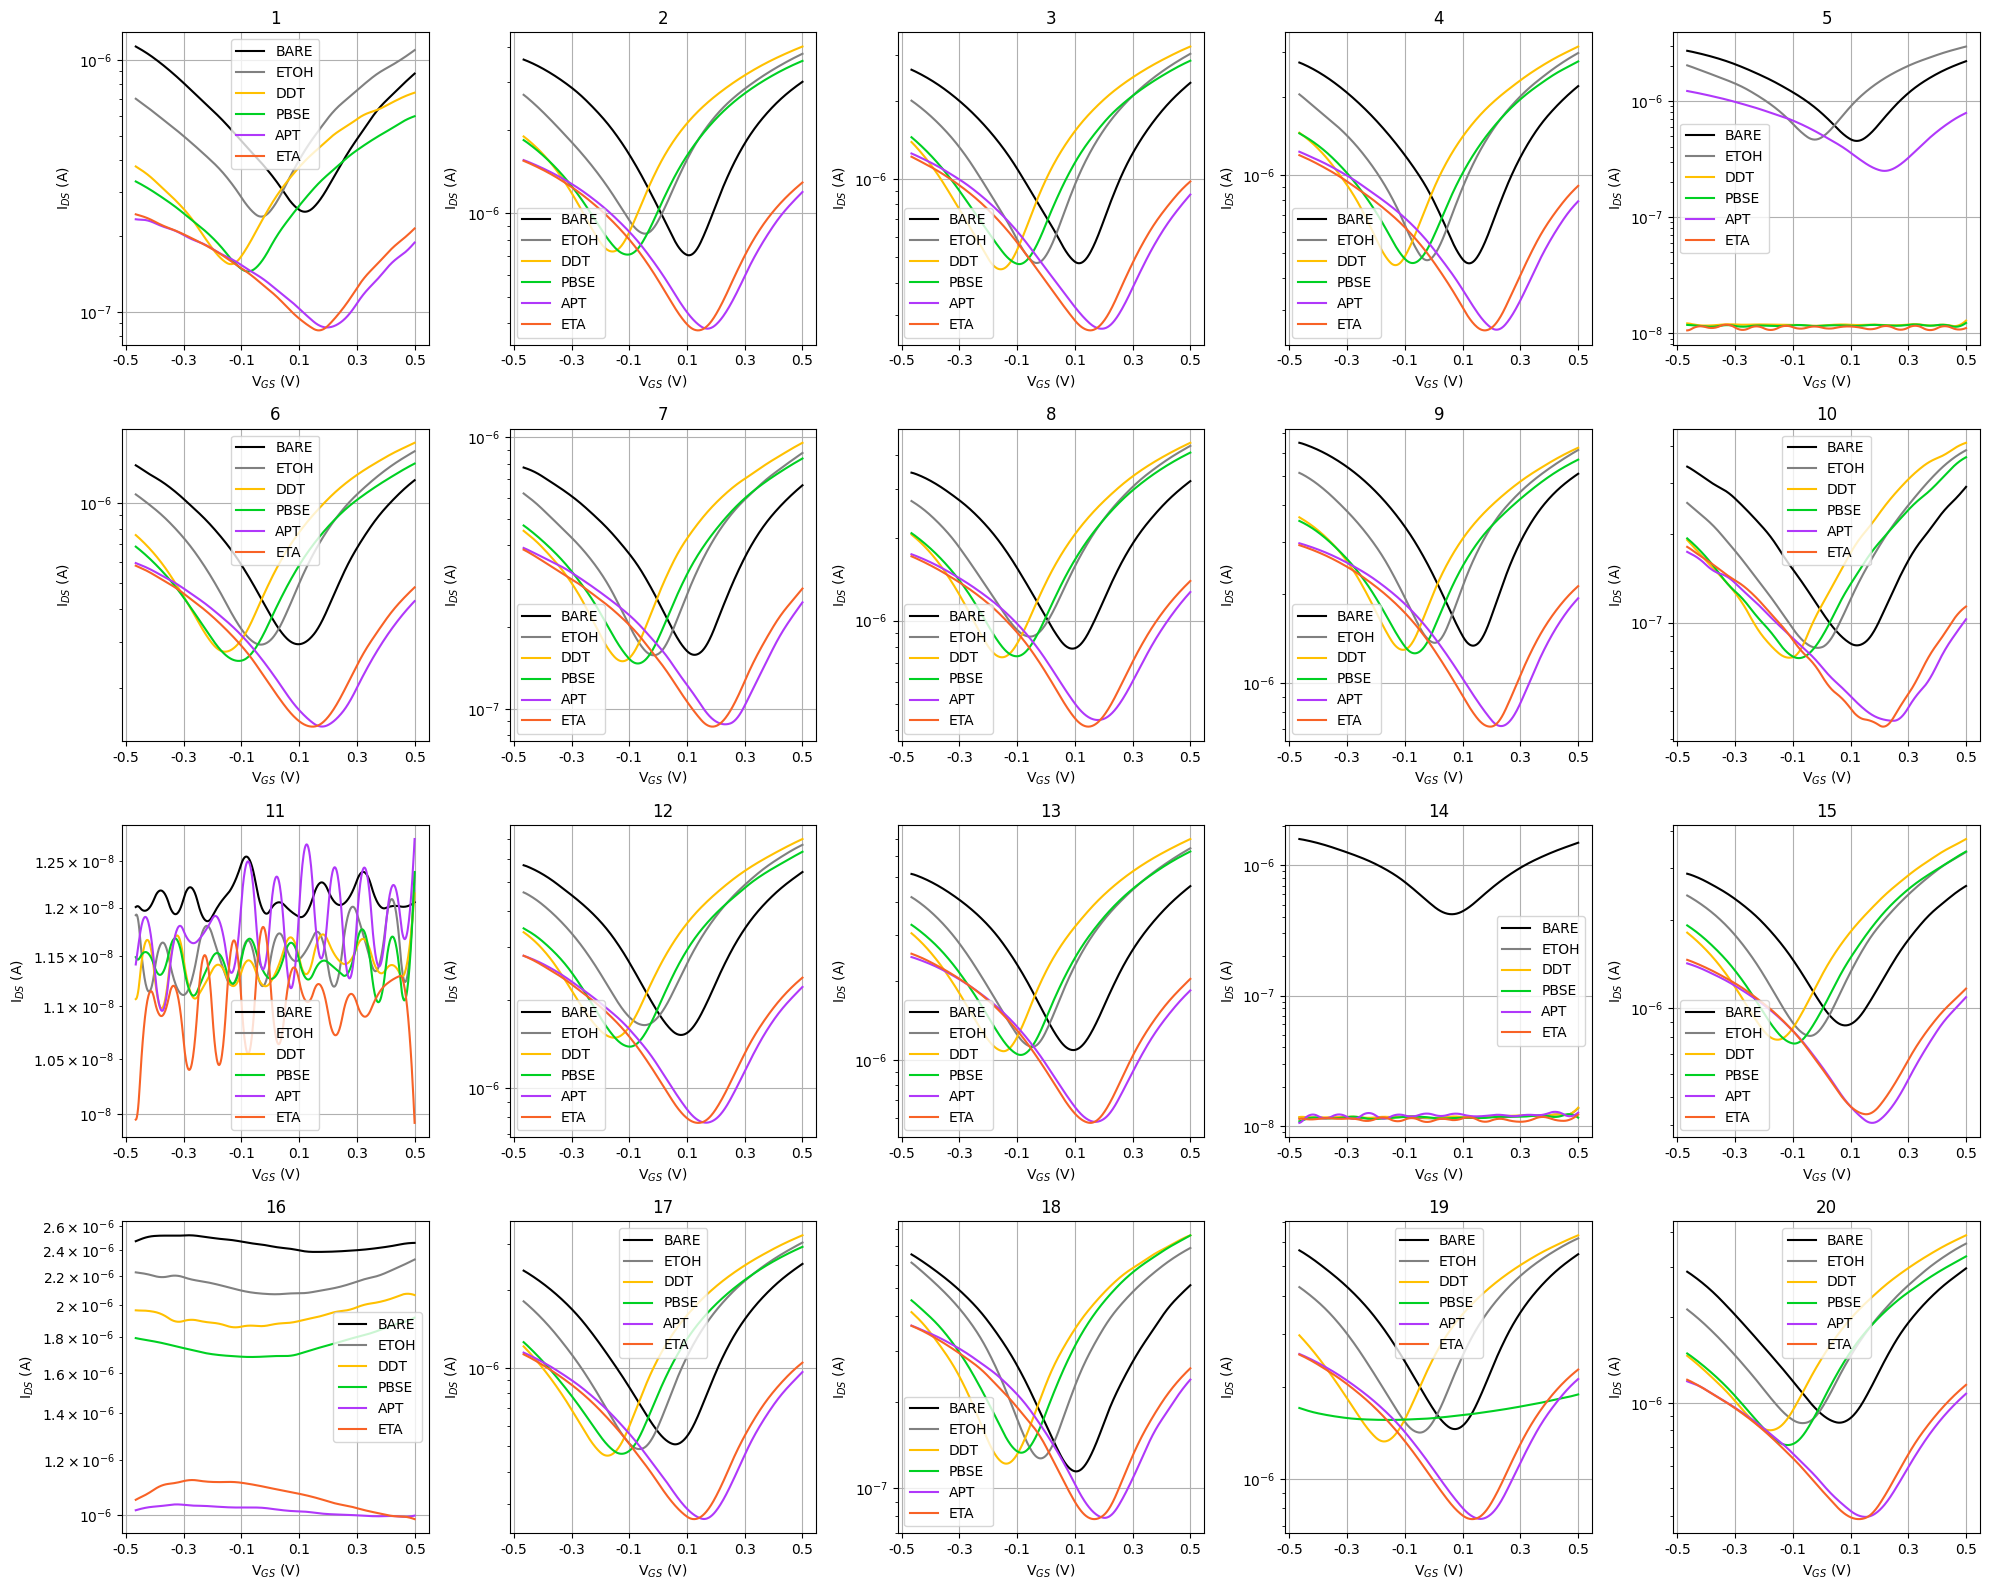

Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_1.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_2.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_3.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_4.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_5.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_6.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_7.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_8.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19abr_C1/Curva_Transferencia_19abr_C1_9.png
Figura salva em: /content/gdrive/MyDrive/GFETS Ju INL/19abr/19ab

In [ ]:
### AQUI VAMOS FAZER TODOS OS GRÁFICOS DAS CURVAS PARA TODOS OS TRANSISTORES E TODAS AS ETAPAS

# Lista de opções para o eixo Y (substitua com os nomes reais das colunas)
colunas_disponiveis = list(bare.columns)
colunas_disponiveis.remove("V_G")  # Remove "V_G" da lista, pois ele é fixo no eixo X

# Converter os valores de V_G para float
for df in [bare, etoh, ddt, pbse, eta]:
    df["V_G"] = df["V_G"].astype(float)

# Criar subplots para visualizar todos os gráficos
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="white")  # 4 linhas, 5 colunas
axes = axes.flatten()

# Gerar gráficos para cada coluna disponível
for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Plot das curvas ###voce pode comentar as curvas que não quiser fazer o grafico ainda, se quiser acompanhar o andamento do processo
    ax.plot(bare["V_G"], bare[coluna], color='black', linestyle='-', label="BARE")
    ax.plot(etoh["V_G"], etoh[coluna], color='grey', linestyle='-', label="ETOH")
    ax.plot(ddt["V_G"], ddt[coluna], color='#FFC000', linestyle='-', label="DDT")
    ax.plot(pbse["V_G"], pbse[coluna], color='#00D023', linestyle='-', label="PBSE")
    ax.plot(apt["V_G"], apt[coluna], color='#B038FA', linestyle='-', label="APT")
    ax.plot(eta["V_G"], eta[coluna], color='#F86226', linestyle='-', label="ETA")


    # Configuração dos eixos e título
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"{coluna}")
    ax.set_yscale("log")
    ax.grid(True)

    # Definir os valores do eixo X manualmente
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(x) for x in x_ticks])

    ax.legend()

plt.tight_layout()
plt.show()
### aqui você vai salvar uma figura com todos os graficos
# Salvar todas as figuras
for idx, coluna in enumerate(colunas_disponiveis):
  caminho = f"{pasta_resultados}/Curva_Transferencia_{CHIP}_{coluna}.png"
  fig.savefig(caminho, dpi=400, bbox_inches='tight')
  print(f"Figura salva em: {caminho}")



In [ ]:
###aqui voce pode escolher um device apenas e salvar a sua figura separadamente!
## não se preocupe em confundir os resultados, o numero do chip é mostrado na figura e o numero do transistor está no nome da figura salva
# Lista de opções para o eixo Y (substitua com os nomes reais das colunas)
colunas_disponiveis = list(bare.columns)
colunas_disponiveis.remove("V_G")  # Remove "V_G" da lista, pois ele é fixo no eixo X

# Converter os valores de V_G para float
for df in [bare]:#, etoh, ddt, pbse, apt, eta]:
    df["V_G"] = df["V_G"].astype(float)

# Dropdown para escolher a coluna
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")

# Botões para gerar e salvar o gráfico
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    global fig  # Torna a figura acessível para salvamento posterior
    fig, ax = plt.subplots(figsize=(8,6), facecolor="white")

    # Plot das curvas
    ax.plot(bare["V_G"], bare[coluna_selector.value], color='black', linestyle='-', label="BARE")
    ax.plot(etoh["V_G"], etoh[coluna_selector.value], color='grey', linestyle='-', label="ETOH")
    ax.plot(ddt["V_G"], ddt[coluna_selector.value], color='#FFC000', linestyle='-', label="DDT")
    ax.plot(pbse["V_G"], pbse[coluna_selector.value], color='#00D023', linestyle='-', label="PBSE")
    ax.plot(apt["V_G"], apt[coluna_selector.value], color='#B038FA', linestyle='-', label="APT")
    ax.plot(eta["V_G"], eta[coluna_selector.value], color='#F86226', linestyle='-', label="ETA")


    # Configuração dos eixos e título
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title("Curva de Transferência do GFET")
    ax.set_yscale("log")
    ax.grid(True)

    # Definir os valores do eixo X manualmente
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(x) for x in x_ticks])

    ax.legend()
    plt.show()

# Função para salvar a figura
def salvar_figura(b):
    if 'fig' in globals():  # Verifica se a figura já foi gerada
        caminho = f"{pasta_resultados}/Curva_Transferencia_{CHIP}_dev{coluna_selector.value}.png"
        fig.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar as funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

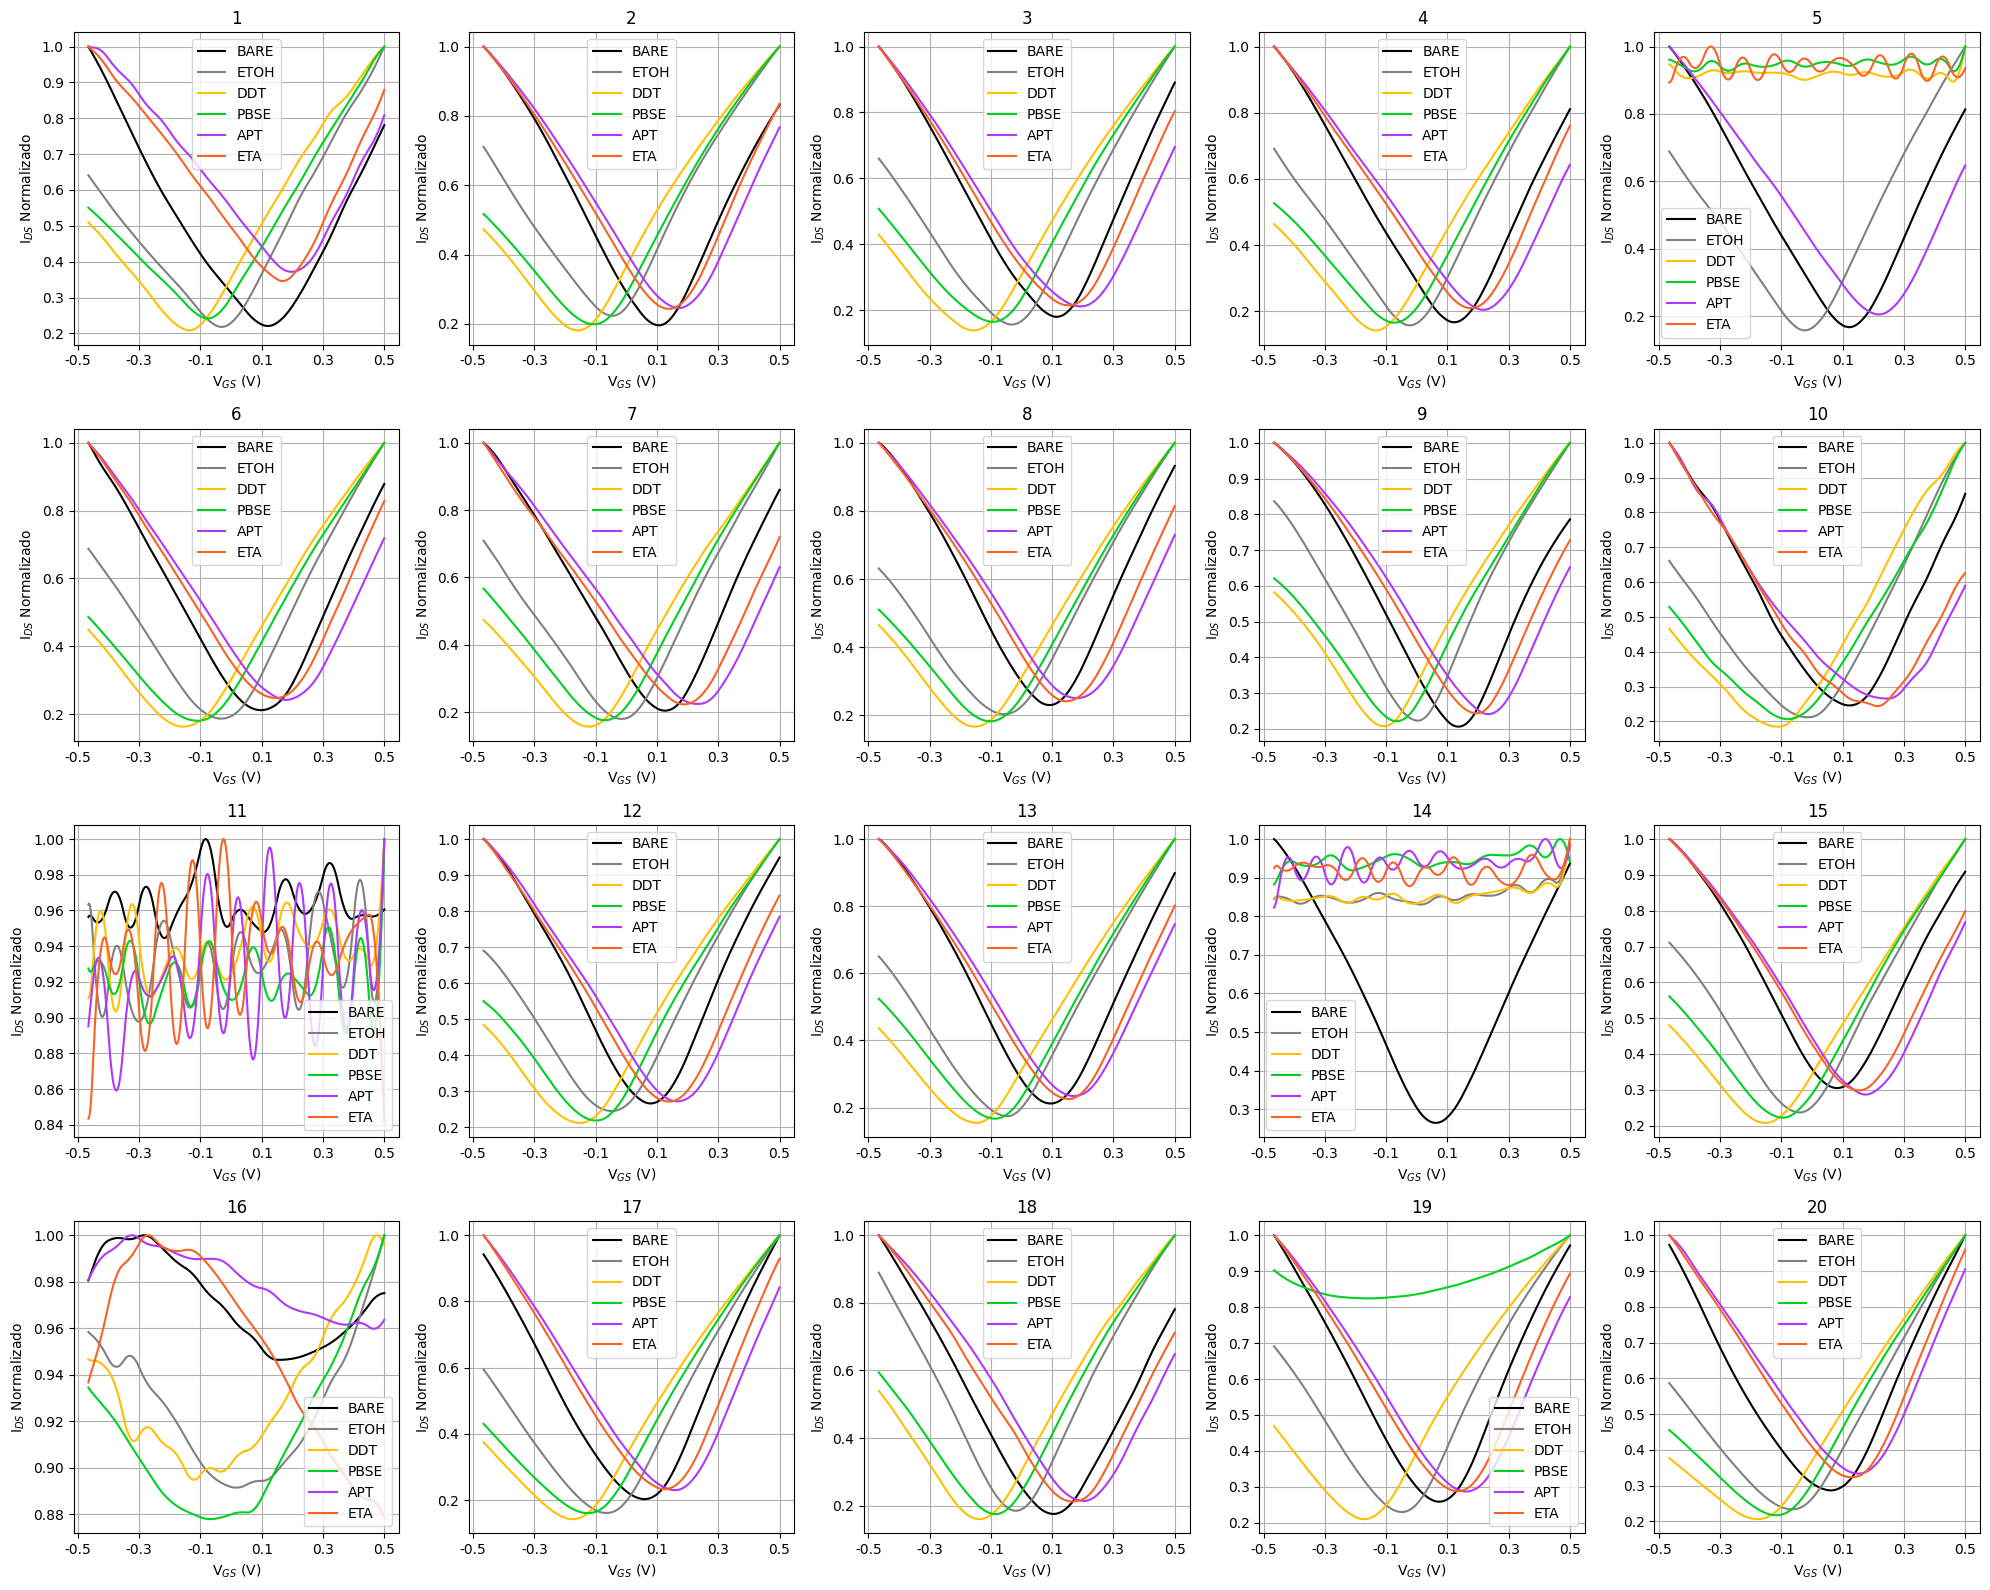

In [ ]:
import matplotlib.pyplot as plt

### AQUI VAMOS FAZER TODOS OS GRÁFICOS DAS CURVAS NORMALIZADAS PARA TODOS OS TRANSISTORES E TODAS AS ETAPAS

# Lista de opções para o eixo Y (substitua com os nomes reais das colunas)
colunas_disponiveis = list(bare.columns)
colunas_disponiveis.remove("V_G")  # Remove "V_G" da lista, pois ele é fixo no eixo X

# Converter os valores de V_G para float
for df in [bare, etoh, ddt, pbse, apt, eta]:
    df["V_G"] = df["V_G"].astype(float)

# Criar subplots para visualizar todos os gráficos
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="white")  # 4 linhas, 5 colunas
axes = axes.flatten()

# Gerar gráficos normalizados para cada coluna disponível
for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Normalização das curvas pelo valor máximo de cada etapa
    bare_norm = bare[coluna] / bare[coluna].max()
    etoh_norm = etoh[coluna] / etoh[coluna].max()
    ddt_norm  = ddt[coluna]  / ddt[coluna].max()
    pbse_norm = pbse[coluna] / pbse[coluna].max()
    apt_norm  = apt[coluna]  / apt[coluna].max()
    eta_norm  = eta[coluna]  / eta[coluna].max()

    # Plot das curvas normalizadas
    ax.plot(bare["V_G"], bare_norm, color='black', linestyle='-', label="BARE")
    ax.plot(etoh["V_G"], etoh_norm, color='grey', linestyle='-', label="ETOH")
    ax.plot(ddt["V_G"], ddt_norm, color='#FFC000', linestyle='-', label="DDT")
    ax.plot(pbse["V_G"], pbse_norm, color='#00D023', linestyle='-', label="PBSE")
    ax.plot(apt["V_G"], apt_norm, color='#B038FA', linestyle='-', label="APT")
    ax.plot(eta["V_G"], eta_norm, color='#F86226', linestyle='-', label="ETA")

    # Configuração dos eixos e título
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ Normalizado")
    ax.set_title(f"{coluna}")
    ax.grid(True)

    # Definir os valores do eixo X manualmente
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(x) for x in x_ticks])

    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:


### aqui você pode escolher um device apenas e salvar a sua figura separadamente!
# não se preocupe em confundir os resultados, o número do chip é mostrado na figura e o número do transistor está no nome da figura salva

# Lista de opções para o eixo Y (substitua com os nomes reais das colunas)
colunas_disponiveis = list(bare.columns)
colunas_disponiveis.remove("V_G")  # Remove "V_G" da lista, pois ele é fixo no eixo X

# Converter os valores de V_G para float
for df in [bare, etoh, ddt, pbse, apt, eta]:
    df["V_G"] = df["V_G"].astype(float)

# Dropdown para escolher a coluna
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")

# Botões para gerar e salvar o gráfico
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    global fig  # Torna a figura acessível para salvamento posterior
    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    coluna = coluna_selector.value

    # Normalização das curvas pelo valor máximo de cada etapa
    bare_norm = bare[coluna] / bare[coluna].max()
    etoh_norm = etoh[coluna] / etoh[coluna].max()
    ddt_norm  = ddt[coluna]  / ddt[coluna].max()
    pbse_norm = pbse[coluna] / pbse[coluna].max()
    apt_norm  = apt[coluna]  / apt[coluna].max()
    eta_norm  = eta[coluna]  / eta[coluna].max()

    # Plot das curvas normalizadas
    ax.plot(bare["V_G"], bare_norm, color='black', linestyle='-', label="BARE")
    ax.plot(etoh["V_G"], etoh_norm, color='grey', linestyle='-', label="ETOH")
    ax.plot(ddt["V_G"], ddt_norm, color='#FFC000', linestyle='-', label="DDT")
    ax.plot(pbse["V_G"], pbse_norm, color='#00D023', linestyle='-', label="PBSE")
    ax.plot(apt["V_G"], apt_norm, color='#B038FA', linestyle='-', label="APT")
    ax.plot(eta["V_G"], eta_norm, color='#F86226', linestyle='-', label="ETA")

    # Configuração dos eixos e título
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ Normalizado")
    ax.set_title("Curva de Transferência Normalizada do GFET")
    ax.grid(True)

    # Definir os valores do eixo X manualmente
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(x) for x in x_ticks])

    ax.legend()
    plt.show()

# Função para salvar a figura
def salvar_figura(b):
    if 'fig' in globals():  # Verifica se a figura já foi gerada
        caminho = f"{pasta_resultados}/Curva_Transferencia_Normalizada_{CHIP}_dev{coluna_selector.value}.png"
        fig.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar as funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

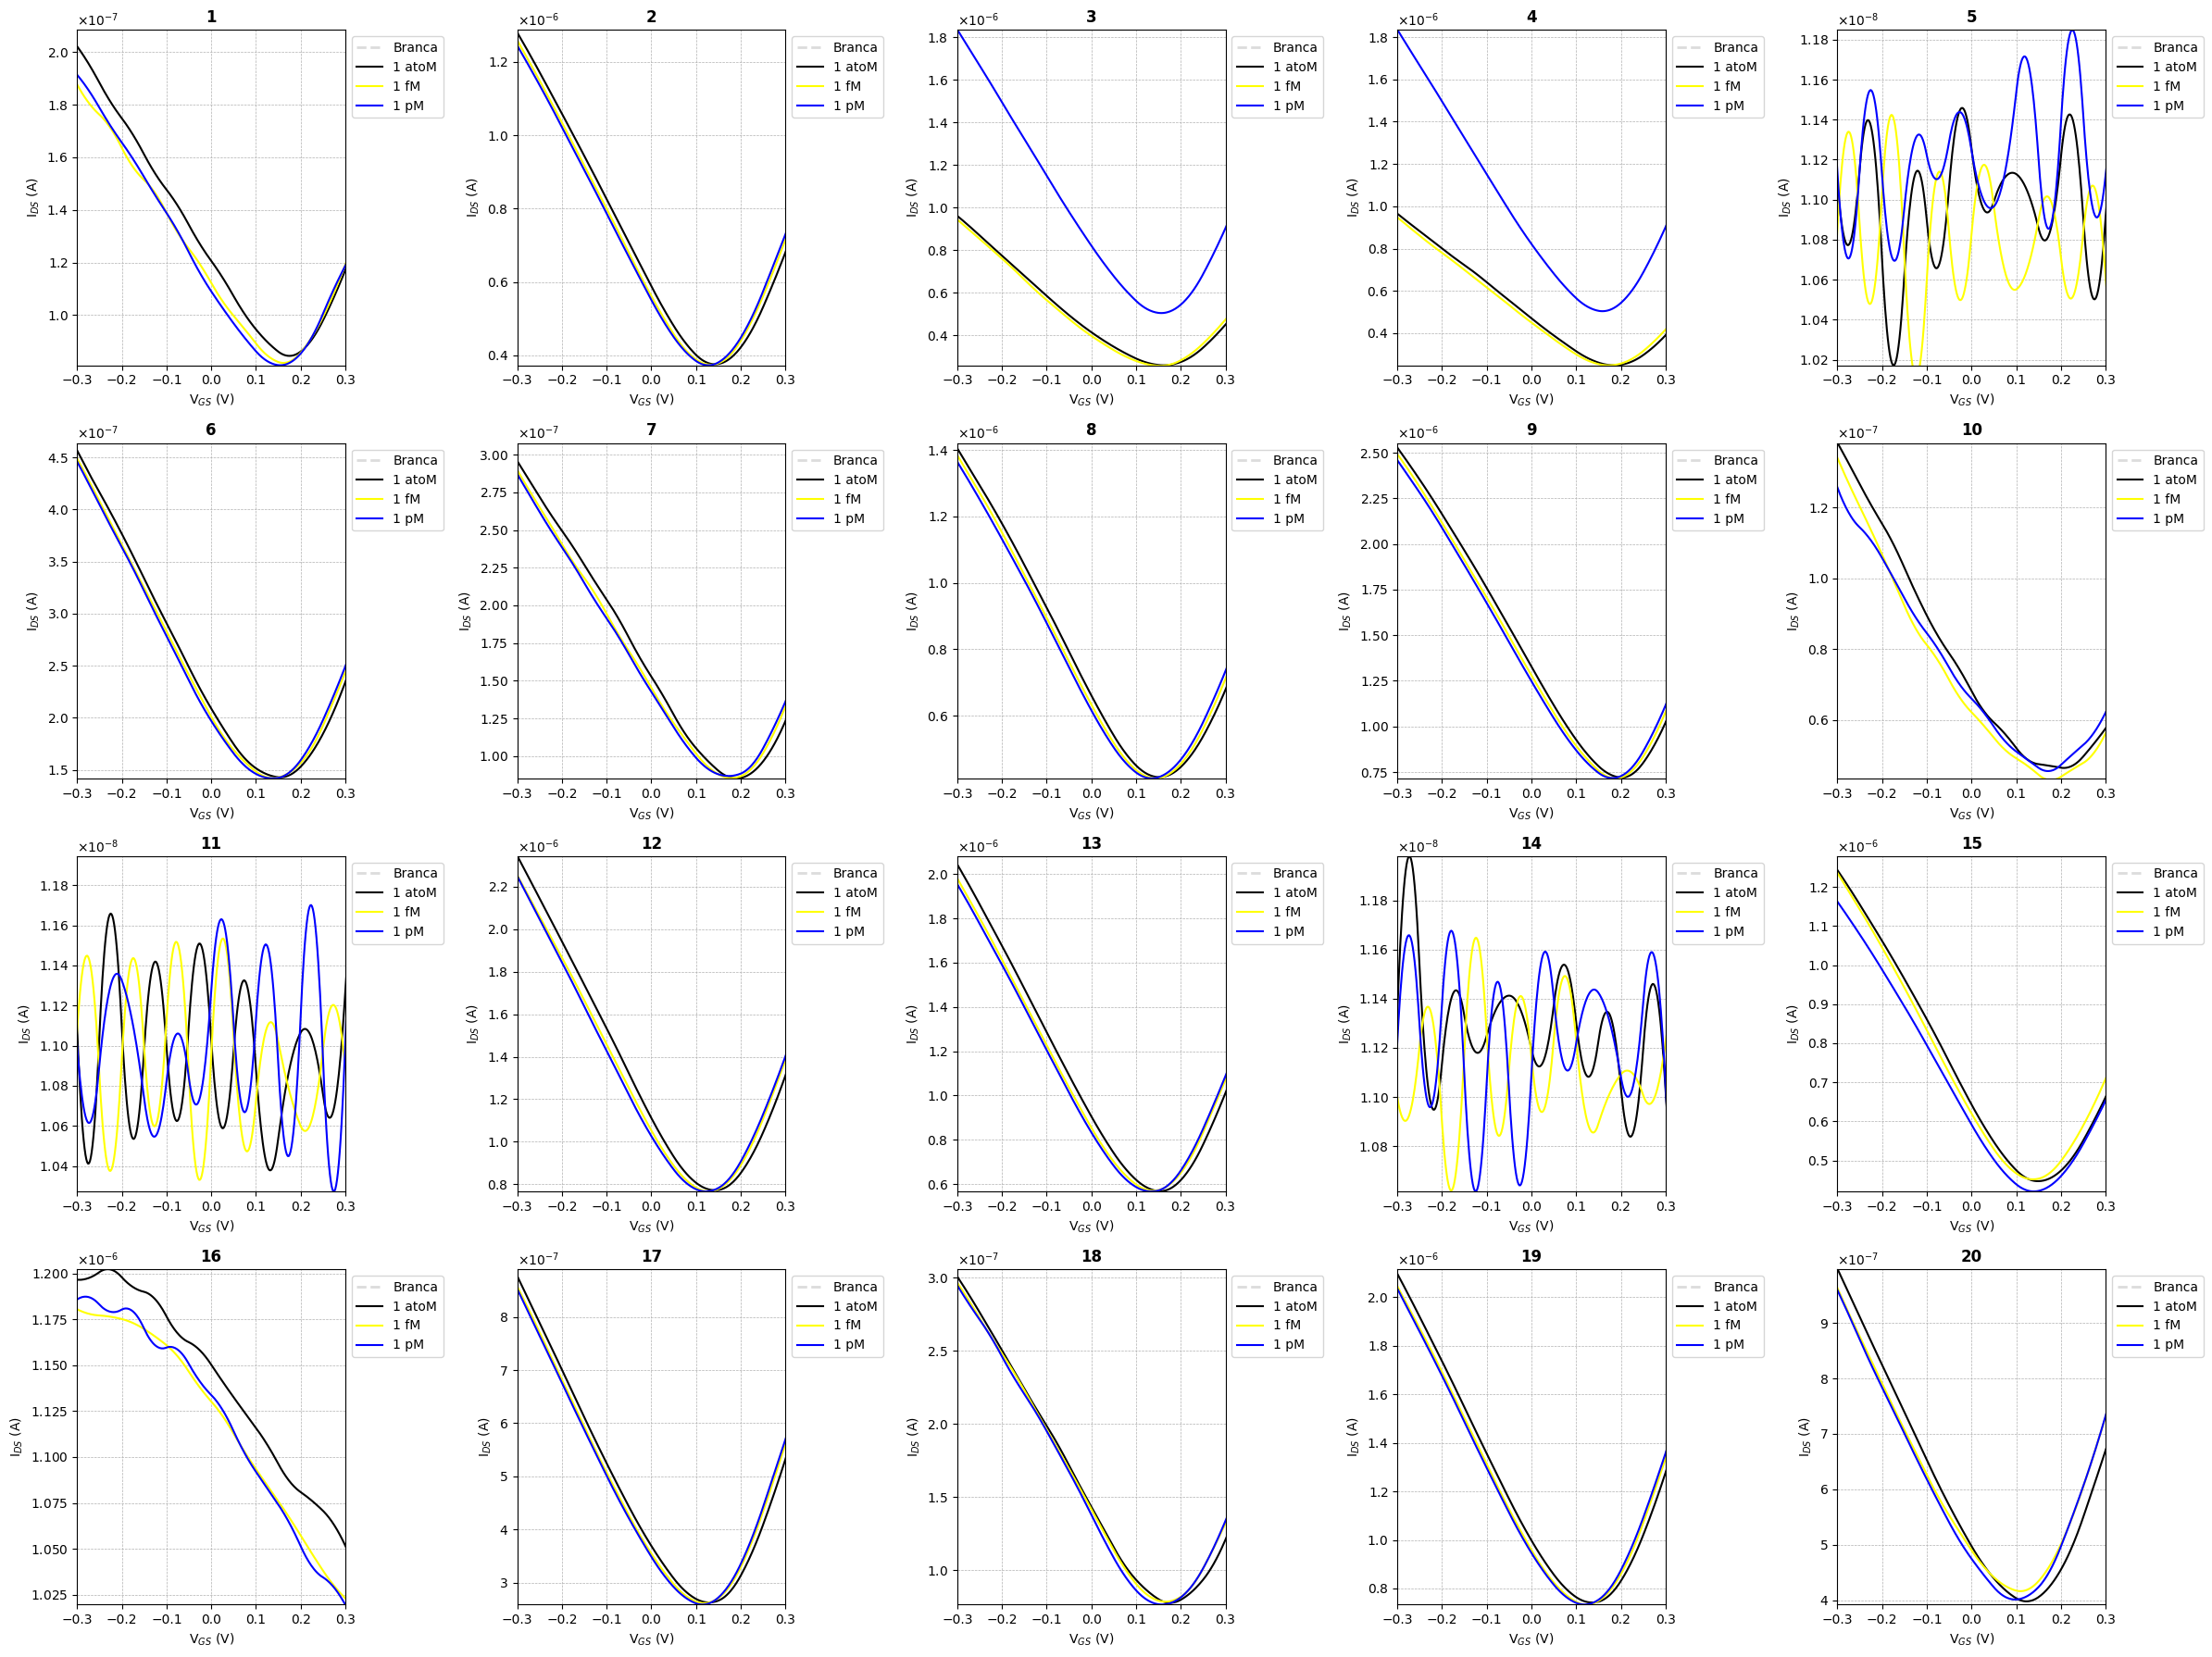

In [ ]:
# Converter todas as colunas numéricas dos BLANKs para float
for df in [b1, b2,b3]:
    for col in colunas_disponiveis:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors='coerce'
        )

# Calcular a média dos três BLANKs
b_avg = b1.copy()
for col in colunas_disponiveis:
    b_avg[col] = (b1[col] + b2[col] + b3[col]) / 3

# Criar subplots com tamanho maior
fig, axes = plt.subplots(4, 5, figsize=(24, 18), facecolor="white")
axes = axes.flatten()

for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Plotando os dados
    #ax.plot(b2["V_G"], b2[coluna], color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(b_avg["V_G"], b_avg[coluna_selector.value]/max(b_avg[coluna_selector.value]), color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(menos18["V_G"], menos18[coluna], color='black', linestyle='-', linewidth=1.5, label="1 atoM")
    #ax.plot(menos17["V_G"], menos17[coluna], color='brown', linestyle='-', linewidth=1.5, label="10 atoM")
    #ax.plot(menos16["V_G"], menos16[coluna], color='red', linestyle='-', linewidth=1.5, label="100 atoM")
    ax.plot(menos15["V_G"], menos15[coluna], color='yellow', linestyle='-', linewidth=1.5, label="1 fM")
    #ax.plot(menos14["V_G"], menos14[coluna], color='yellow', linestyle='-', linewidth=1.5, label="10 fM")
    #ax.plot(menos13["V_G"], menos13[coluna], color='green', linestyle='-', linewidth=1.5, label="100 fM")
    ax.plot(menos12["V_G"], menos12[coluna], color='blue', linestyle='-', linewidth=1.5, label="1 pM")
    #ax.plot(menos11["V_G"], menos11[coluna], color='purple', linestyle='-', linewidth=1.5, label="10 pM")
    #ax.plot(menos10["V_G"], menos10[coluna], color='magenta', linestyle='-', linewidth=1.5, label="100 pM")
    #ax.plot(menos9["V_G"], menos9[coluna], color='magenta', linestyle='-', linewidth=1.5, label="1 nM")
    #ax.plot(menos8["V_G"], menos8[coluna], color='black', linestyle='-', linewidth=1.5, label="10 nM")
    #ax.plot(c10ng["V_G"], c10ng[coluna], color='#ff007f', linestyle='-', linewidth=1.5, label="74 pM")
    #ax.plot(c25ng["V_G"], c25ng[coluna], color='#e2619f', linestyle='-', linewidth=1.5, label="185 pM")
    #ax.plot(c50ng["V_G"], c50ng[coluna], color='#ff3665', linestyle='-', linewidth=1.5, label="370 pM")
    #ax.plot(c75ng["V_G"], c75ng[coluna], color='#a21545', linestyle='-', linewidth=1.5, label="556 pM")
    #ax.plot(c100ng["V_G"], c100ng[coluna], color='#a5047b', linestyle='-', linewidth=1.5, label="741 pM")


    # Selecionar região de interesse
    x_min, x_max = -0.3, 0.3  # Ajuste do eixo X

    mask = (b2["V_G"] >= x_min) & (b2["V_G"] <= x_max)

    # Pegar valores de Y dentro dessa região para todos os conjuntos de dados
    y_vals = np.concatenate([
        b2.loc[mask, coluna],
        menos18.loc[mask, coluna],
        menos12.loc[mask, coluna]
    ])

    # Evitar problemas se não houver dados na região filtrada
    if len(y_vals) > 0:
        y_min, y_max = np.min(y_vals), np.max(y_vals)
        if y_min == y_max:
            y_max = y_min * 200  # Evita eixo colapsado
    else:
        y_min, y_max = 1e-15, 1e-8  # Valores padrão para evitar erro

    # Ajustar limites dos eixos
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Formatação dos eixos
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"{coluna}", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação científica do eixo Y
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda fora do gráfico
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Salvar figura em alta resolução (DPI 300)
plt.tight_layout()
caminho = f"{pasta_resultados}/Curva_Normal_{CHIP}_ALL.png"
plt.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")  # <- aqui
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value  # Obtém a coluna selecionada

    if not coluna:
        print("Selecione uma coluna válida.")
        return

    # Criar figura
    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Plotando os dados selecionados
    # Plotando os dados
    #ax.plot(b2["V_G"], b2[coluna], color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(b_avg["V_G"], b_avg[coluna_selector.value]/max(b_avg[coluna_selector.value]), color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(menos18["V_G"], menos18[coluna], color='black', linestyle='-', linewidth=1.5, label="1 atoM")
    #ax.plot(menos17["V_G"], menos17[coluna], color='brown', linestyle='-', linewidth=1.5, label="10 atoM")
    #ax.plot(menos16["V_G"], menos16[coluna], color='red', linestyle='-', linewidth=1.5, label="100 atoM")
    ax.plot(menos15["V_G"], menos15[coluna], color='yellow', linestyle='-', linewidth=1.5, label="1 fM")
    #ax.plot(menos14["V_G"], menos14[coluna], color='yellow', linestyle='-', linewidth=1.5, label="10 fM")
    #ax.plot(menos13["V_G"], menos13[coluna], color='green', linestyle='-', linewidth=1.5, label="100 fM")
    ax.plot(menos12["V_G"], menos12[coluna], color='blue', linestyle='-', linewidth=1.5, label="1 pM")
    #ax.plot(menos11["V_G"], menos11[coluna], color='purple', linestyle='-', linewidth=1.5, label="10 pM")
    #ax.plot(menos10["V_G"], menos10[coluna], color='magenta', linestyle='-', linewidth=1.5, label="100 pM")
    #ax.plot(menos9["V_G"], menos9[coluna], color='magenta', linestyle='-', linewidth=1.5, label="1 nM")
    #ax.plot(menos8["V_G"], menos8[coluna], color='black', linestyle='-', linewidth=1.5, label="10 nM")
    #ax.plot(c10ng["V_G"], c10ng[coluna], color='#ff007f', linestyle='-', linewidth=1.5, label="74 pM")
    #ax.plot(c25ng["V_G"], c25ng[coluna], color='#e2619f', linestyle='-', linewidth=1.5, label="185 pM")
    #ax.plot(c50ng["V_G"], c50ng[coluna], color='#ff3665', linestyle='-', linewidth=1.5, label="370 pM")
    #ax.plot(c75ng["V_G"], c75ng[coluna], color='#a21545', linestyle='-', linewidth=1.5, label="556 pM")
    #ax.plot(c100ng["V_G"], c100ng[coluna], color='#a5047b', linestyle='-', linewidth=1.5, label="741 pM")

    # Selecionar região de interesse
    x_min, x_max = -0.15, 0.35
    mask = (b2["V_G"] >= x_min) & (b2["V_G"] <= x_max)

    # Pegar valores de Y dentro dessa região
    y_vals = np.concatenate([
        b2.loc[mask, coluna],
        menos18.loc[mask, coluna],
        menos12.loc[mask, coluna]
    ])

    # Definir limites do eixo Y
    if len(y_vals) > 0:
        y_min, y_max = np.min(y_vals), np.max(y_vals)
        if y_min == y_max:
            y_max = y_min * 1.1  # Evita eixo colapsado
    else:
        y_min, y_max = 0.3  #1e-9, 1e-8  # Valores padrão

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Formatação dos eixos
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação científica do eixo Y
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda fora do gráfico
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Atualizar figura global
    global fig_to_save
    fig_to_save = fig  # Armazena para salvamento posterior
    #plt.show()
    plt.show(block=True)  # Bloqueia a execução até fechar a janela


# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():  # Verifica se a figura já foi gerada
        caminho =  f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar as funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

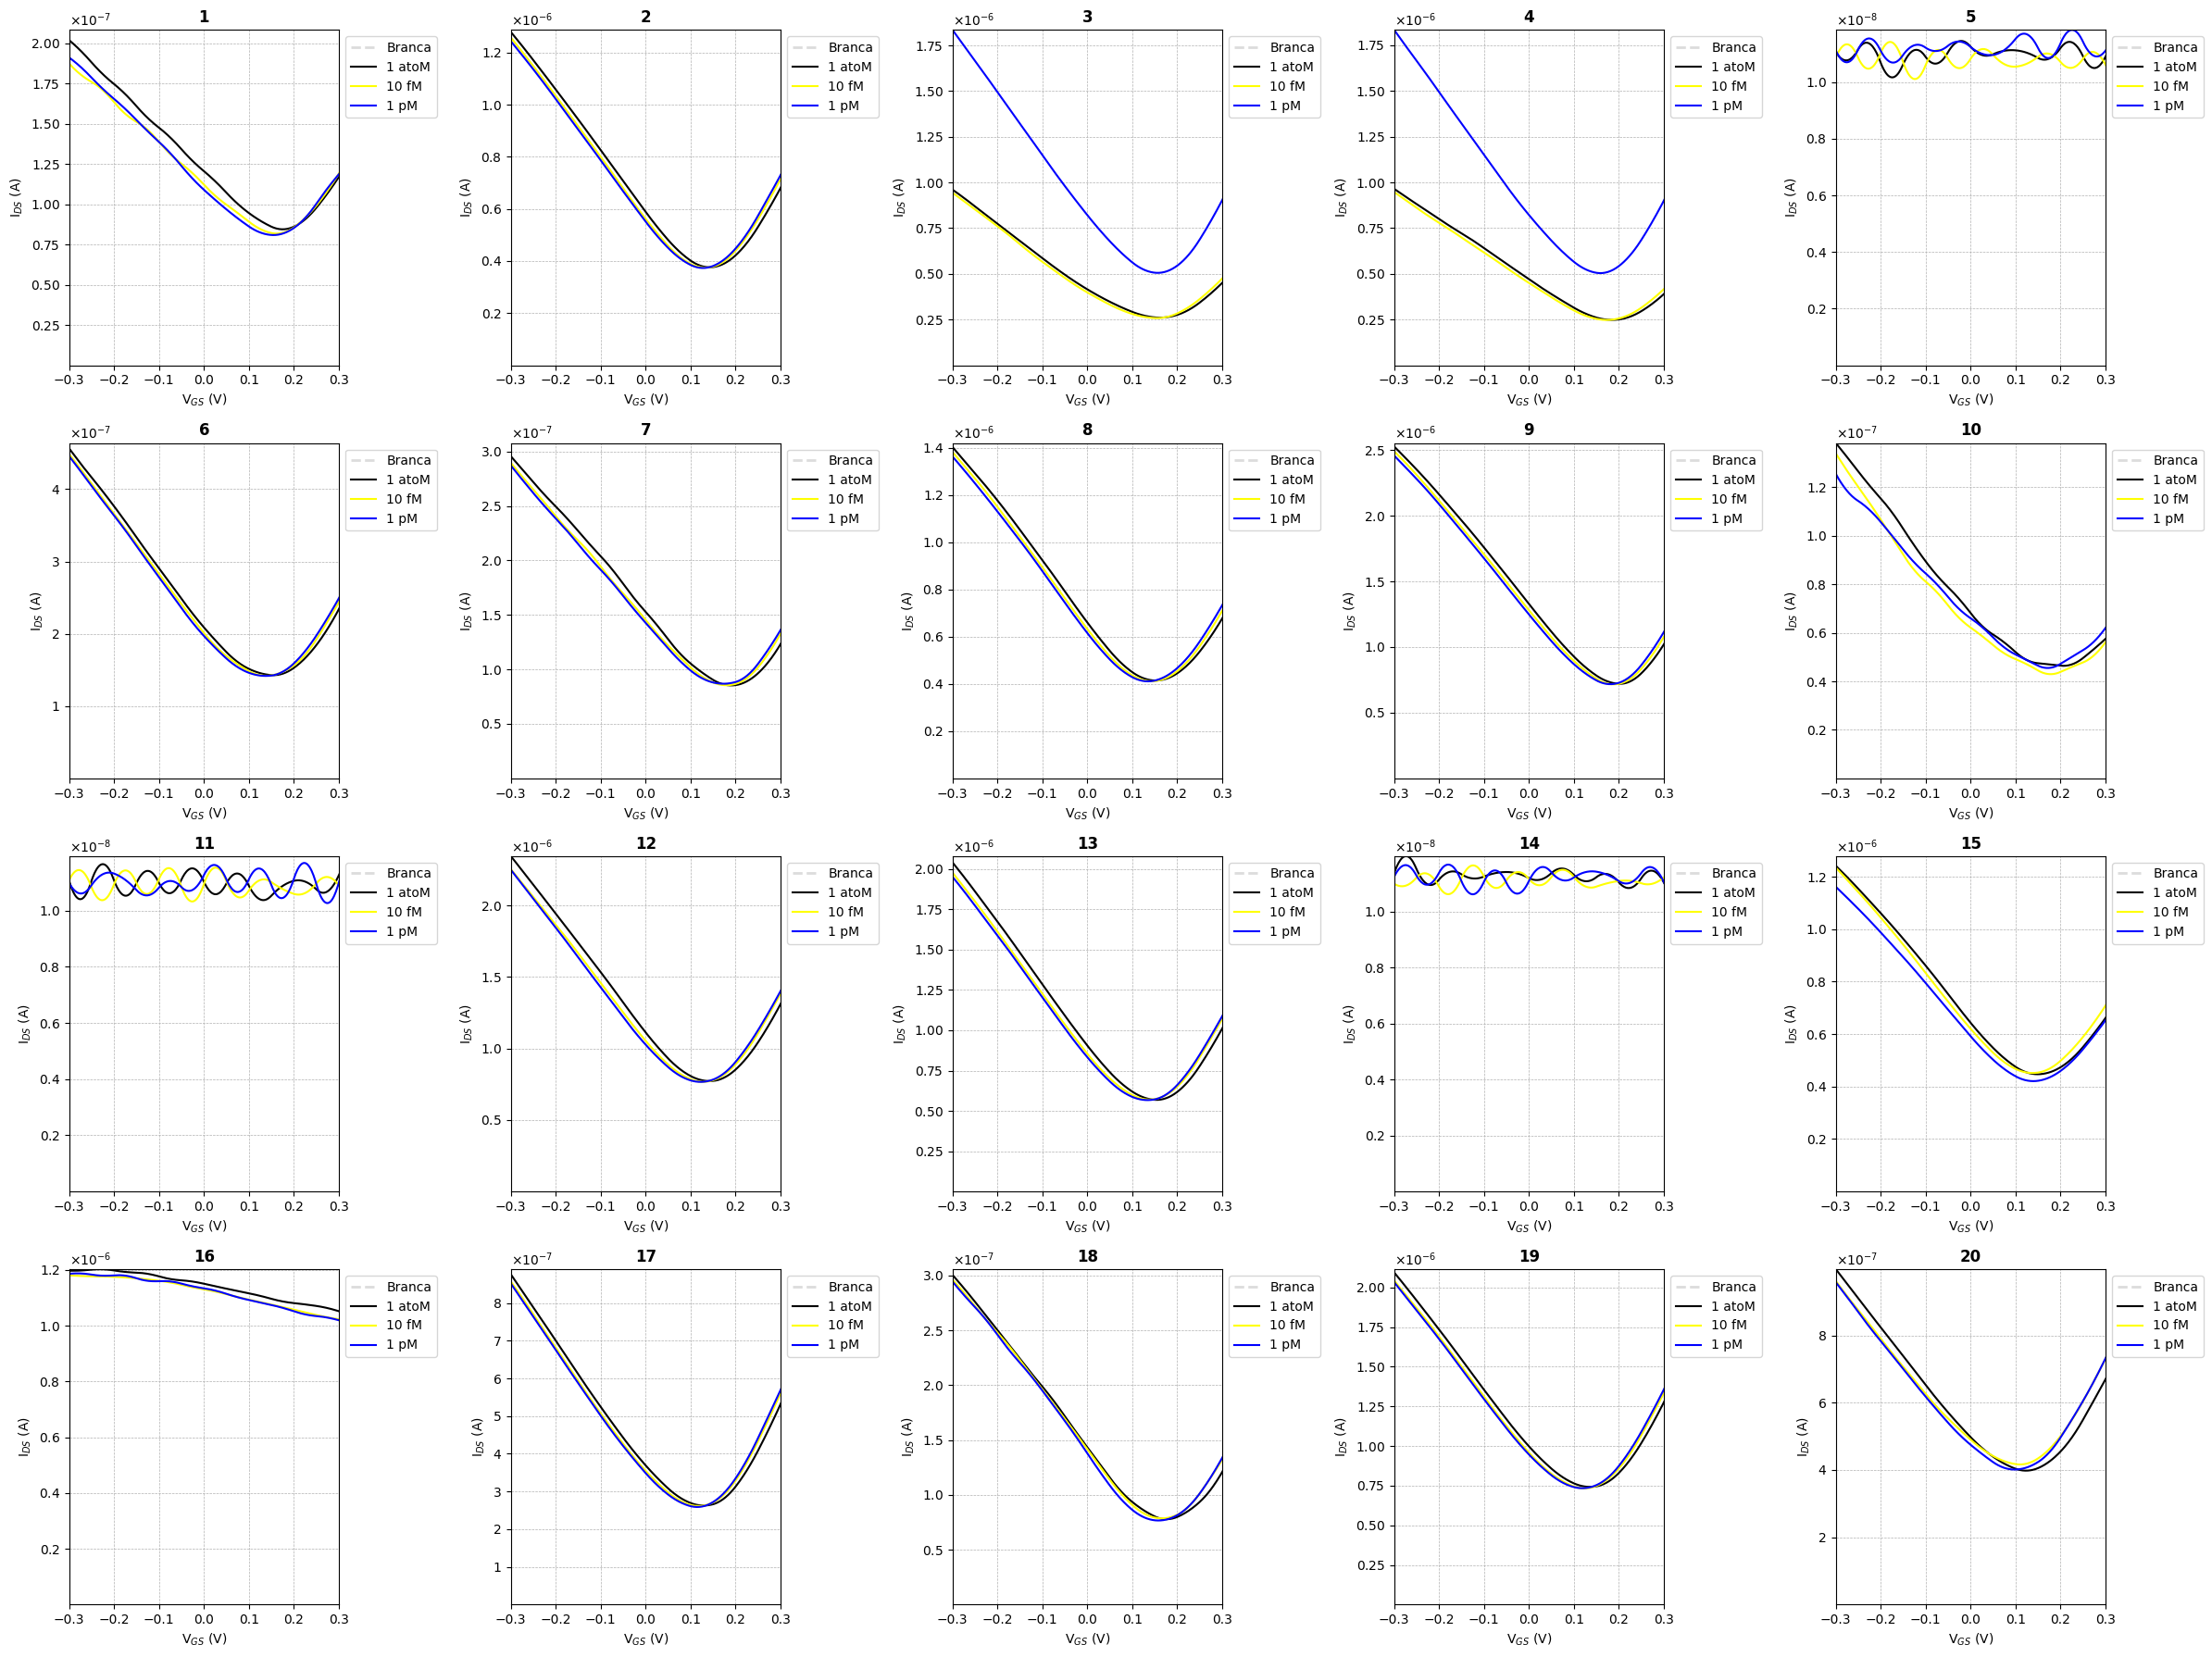

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pasta_resultados = '/content/gdrive/MyDrive/GFETS Ju INL/RESULTADOSdoc'
#CHIP = '29MARC1'

# Converter todas as colunas numéricas dos BLANKs para float
for df in [b1, b2, b3]:
    for col in colunas_disponiveis:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors='coerce'
        )

# Calcular a média dos três BLANKs
b_avg = b1.copy()
for col in colunas_disponiveis:
    b_avg[col] = (b1[col] + b2[col] + b3[col]) / 3

# Criar subplots com tamanho maior
fig, axes = plt.subplots(4, 5, figsize=(24, 18), facecolor="white")
axes = axes.flatten()

for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    #Plotando a curva média normalizada (Branca)
    ax.plot(
        b_avg["V_G"],
        b_avg[coluna] / max(b_avg[coluna]),
        color='#DCDCDC',
        linestyle='--',
        linewidth=2,
        label="Branca"
    )

    # Outras curvas comentadas, você pode ativar conforme desejar:
    ax.plot(menos18["V_G"], menos18[coluna], color='black', linestyle='-', linewidth=1.5, label="1 atoM")
    #ax.plot(menos16["V_G"], menos16[coluna], color='red', linestyle='-', linewidth=1.5, label="100 atoM")
    #ax.plot(menos14["V_G"], menos14[coluna], color='yellow', linestyle='-', linewidth=1.5, label="10 fM")
    ax.plot(menos15["V_G"], menos15[coluna], color='yellow', linestyle='-', linewidth=1.5, label="10 fM")
    ax.plot(menos12["V_G"], menos12[coluna], color='blue', linestyle='-', linewidth=1.5, label="1 pM")
    #ax.plot(menos10["V_G"], menos10[coluna], color='magenta', linestyle='-', linewidth=1.5, label="100 pM")
    #ax.plot(menos9["V_G"], menos9[coluna], color='magenta', linestyle='-', linewidth=1.5, label="100 pM")

    # Selecionar região de interesse
    x_min, x_max = -0.3, 0.3
    mask = (b2["V_G"] >= x_min) & (b2["V_G"] <= x_max)

    # Pegar valores de Y dentro dessa região
    y_vals = np.concatenate([
        b2.loc[mask, coluna],
        menos18.loc[mask, coluna],
        menos12.loc[mask, coluna]
    ])

    # Ajustar limites do eixo Y
    if len(y_vals) > 0:
        y_min, y_max = np.min(y_vals), np.max(y_vals)
        if y_min == y_max:
            y_max = y_min * 200  # Evita eixo colapsado
    else:
        y_min, y_max = 1e-15, 1e-8

    # Força exibição de mais parte inferior do gráfico
    y_min = min(y_min, 1e-12)

    # Aplicar limites dos eixos
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Formatação
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"{coluna}", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formato científico do eixo Y
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Salvar figura
plt.tight_layout()
caminho = f"{pasta_resultados}/Curva_Normal_{CHIP}_ALL.png"
plt.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

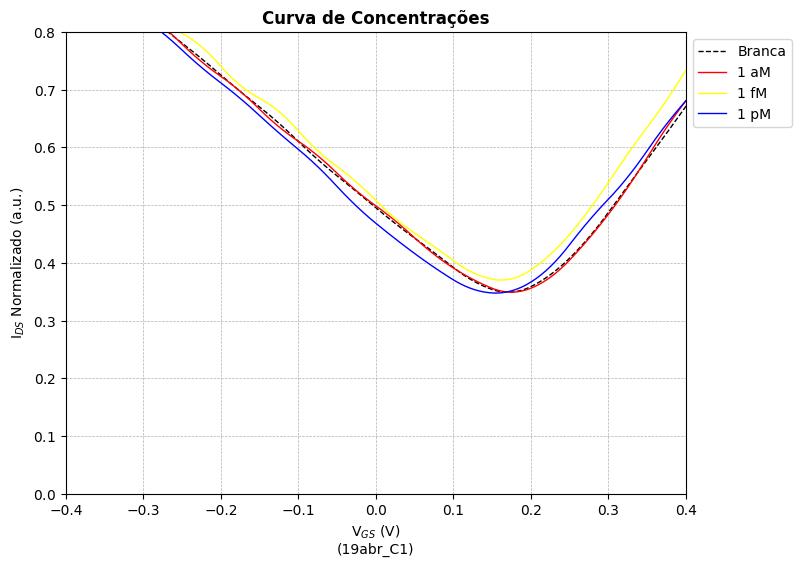

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função de normalização
def normalizar(df, coluna):
    dados = df[coluna]
    max_val = np.max(dados)
    return dados / max_val if max_val != 0 else dados  # evita divisão por zero

# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value  # Obtém a coluna selecionada

    if not coluna:
        print("Selecione uma coluna válida.")
        return

    # Criar figura
    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Plotando os dados normalizados
    ax.plot(b_avg["V_G"], normalizar(b_avg, coluna), color='black', linestyle='--', linewidth=1, label="Branca")
    ax.plot(menos18["V_G"], normalizar(menos18, coluna), color='red', linestyle='-', linewidth=1, label="1 aM")
    #ax.plot(menos16["V_G"], normalizar(menos16, coluna), color='yellow', linestyle='-', linewidth=1, label="1 pM")
    ax.plot(menos15["V_G"], normalizar(menos15, coluna), color='yellow', linestyle='-', linewidth=1, label="1 fM")
    #ax.plot(menos14["V_G"], normalizar(menos14, coluna), color='green', linestyle='-', linewidth=1, label="1 fM")
    ax.plot(menos12["V_G"], normalizar(menos12, coluna), color='blue', linestyle='-', linewidth=1, label="1 pM")
    #ax.plot(c10ng["V_G"], normalizar(c10ng, coluna), color='grey', linestyle='-', alpha=0.5,linewidth=1.5, label="74 pM")
    #ax.plot(c25ng["V_G"], normalizar(c25ng, coluna), color='green', linestyle='-', alpha=0.5,linewidth=1.5, label="185 pM")
    #ax.plot(c50ng["V_G"], normalizar(c50ng, coluna), color='yellow', alpha=0.5,linestyle='-', linewidth=1.5, label="370 pM")
    #ax.plot(c75ng["V_G"], normalizar(c75ng, coluna), color='red', alpha=0.5,linestyle='-', linewidth=1.5, label="556 pM")
    #ax.plot(c100ng["V_G"], normalizar(c100ng, coluna), color='magenta', alpha=0.5,linestyle='-', linewidth=1.5, label="741 pM")
    #ax.plot(menos10["V_G"], normalizar(menos10, coluna), color='magenta', linestyle='-', linewidth=1, label="10 nM")
    #ax.plot(menos9["V_G"], normalizar(menos9, coluna), color='magenta', linestyle='-', linewidth=1, label="1 nM")

    # Selecionar região de interesse
    x_min, x_max = -0.4, 0.4
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 0.8)  # Como está tudo normalizado, Y vai de 0 a 1

    # Formatação dos eixos
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ Normalizado (a.u.)")
    ax.set_title(f"Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação científica do eixo Y (se ainda quiser)
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda fora do gráfico
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Atualizar figura global
    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

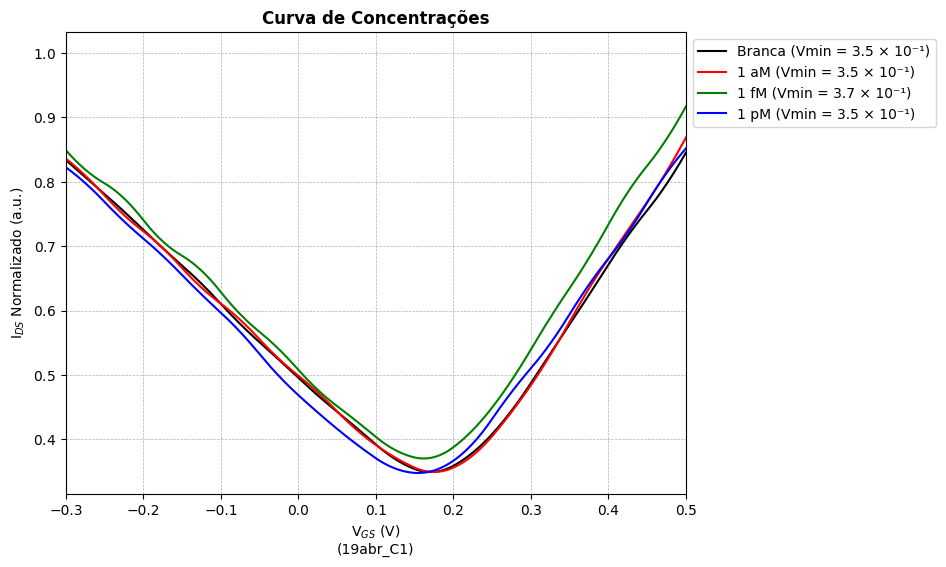

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função de normalização
def normalizar(df, coluna):
    dados = df[coluna]
    max_val = np.max(dados)
    return dados / max_val if max_val != 0 else dados

def formatar_exponencial(valor):
    if valor == 0 or np.isnan(valor):
        return "0"

    valor_sci = f"{valor:.1e}"  # Força notação científica, ex: "4.5e-07"
    mantissa, expoente = valor_sci.split("e")
    expoente = int(expoente)

    # Expoente com números elevados (unicode)
    expoente_formatado = ''.join({
        "-": "⁻", "0": "⁰", "1": "¹", "2": "²", "3": "³",
        "4": "⁴", "5": "⁵", "6": "⁶", "7": "⁷", "8": "⁸", "9": "⁹"
    }[c] for c in str(expoente))

    return f"{mantissa} × 10{expoente_formatado}"


# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value
    if not coluna:
        print("Selecione uma coluna válida.")
        return

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Lista de curvas com (nome, dataframe, cor)
    curvas = [
        ("Branca", b_avg, 'black'),
        ("1 aM", menos18, 'red'),
        ("1 fM", menos15, 'green'),
        ("1 pM", menos12, 'blue'),
        #("1 nM", menos9, 'magenta'),
    ]

    for nome, df, cor in curvas:
        if coluna not in df.columns:
            continue
        dados_norm = normalizar(df, coluna)
        vmin = np.min(dados_norm)
        vmin_str = formatar_exponencial(vmin)
        label = f"{nome} (Vmin = {vmin_str})"
        ax.plot(df["V_G"], dados_norm, color=cor, linestyle='-', linewidth=1.5, label=label)

    # Ajustes dos eixos
    x_min, x_max = -0.3, 0.5
    ax.set_xlim(x_min, x_max)
    #ax.set_ylim(0, 0.8)
    y_min, y_max = 0.1,0.7

    # Eixos
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ Normalizado (a.u.)")
    ax.set_title("Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação do eixo Y
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir widgets
display(coluna_selector, button_plot, button_save)


# **gerando grafico para tese**

Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

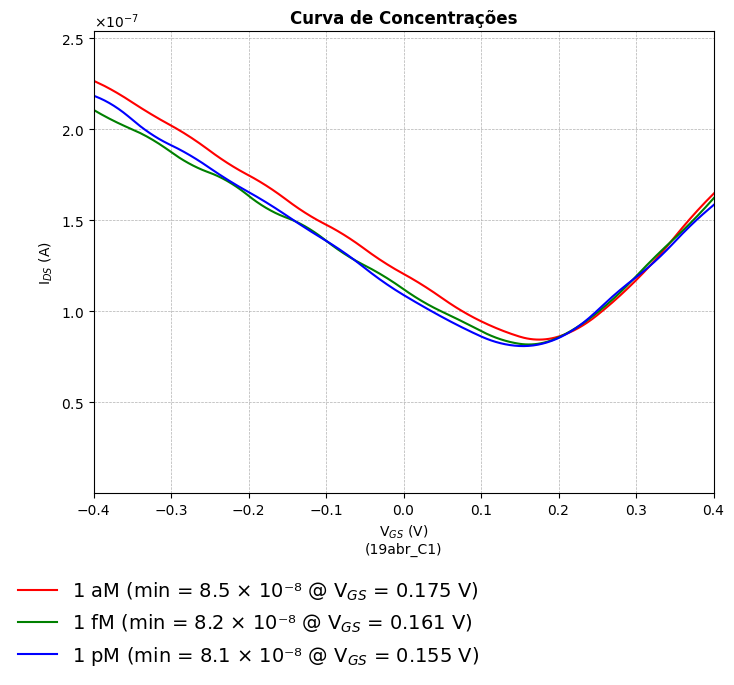

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para formatar valor com potência elevada (ex: 6.5 × 10⁻¹¹)
def formatar_exponencial(valor):
    if valor == 0 or np.isnan(valor):
        return "0"
    base = f"{valor:.2g}".split("e")
    mantissa = base[0]
    expoente = int(base[1])
    expoente_formatado = ''.join({
        "-": "⁻", "0": "⁰", "1": "¹", "2": "²", "3": "³",
        "4": "⁴", "5": "⁵", "6": "⁶", "7": "⁷", "8": "⁸", "9": "⁹"
    }[c] for c in str(expoente))
    return f"{mantissa} × 10{expoente_formatado}"

# Função para gerar o gráfico com dados não normalizados
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value
    if not coluna:
        print("Selecione uma coluna válida.")
        return

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Dicionário com curvas: {label: (dataframe, cor, estilo)}
    curvas = {
        "1 aM": (menos18, 'red', '-'),
        "1 fM": (menos15, 'green', '-'),
        "1 pM": (menos12, 'blue', '-'),
    }

    for nome_base, (df, cor, estilo) in curvas.items():
        if coluna not in df.columns:
            continue

        valores = df[coluna]
        vg = df["V_G"]

        # Encontra o menor valor da corrente e o valor de V_G correspondente
        idx_min = np.nanargmin(valores)
        corrente_min = valores.iloc[idx_min]
        vg_correspondente = vg.iloc[idx_min]

        corrente_fmt = formatar_exponencial(corrente_min)
        vg_fmt = f"{vg_correspondente:.3f}"
        label = f"{nome_base} (min = {corrente_fmt} @ V$_{{GS}}$ = {vg_fmt} V)"

        ax.plot(vg, valores, color=cor, linestyle=estilo, linewidth=1.5, label=label)

    # Eixos
    x_min, x_max = -0.4, 0.4
    ax.set_xlim(x_min, x_max)

    # Determinar y_min e y_max automaticamente
    todos_valores = np.concatenate([df[coluna] for _, (df, _, _) in curvas.items() if coluna in df.columns])
    y_min, y_max = np.nanmin(todos_valores), np.nanmax(todos_valores)
    y_min = min(y_min, 1e-12)
    ax.set_ylim(y_min, y_max * 1.05)

    # Formatação
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{{DS}}$ (A)")
    ax.set_title("Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Eixo Y em notação científica
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.25, -0.15),
        fontsize=14,           # Aumenta o tamanho da fonte
        frameon=False,         # Remove a borda da legenda (opcional)
        ncol=1                 # Ou mais colunas se desejar
    )
    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}_NAO_NORMALIZADA.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para formatar valor com potência elevada (ex: 6.5 × 10⁻¹¹)
def formatar_exponencial(valor):
    if valor == 0 or np.isnan(valor):
        return "0"
    base = f"{valor:.2g}".split("e")
    mantissa = base[0]
    expoente = int(base[1])
    expoente_formatado = ''.join({
        "-": "⁻", "0": "⁰", "1": "¹", "2": "²", "3": "³",
        "4": "⁴", "5": "⁵", "6": "⁶", "7": "⁷", "8": "⁸", "9": "⁹"
    }[c] for c in str(expoente))
    return f"{mantissa} × 10{expoente_formatado}"

# Função para gerar o gráfico com dados normalizados
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value
    if not coluna:
        print("Selecione uma coluna válida.")
        return

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Dicionário com curvas: {label: (dataframe, cor, estilo)}
    curvas = {
        "1 aM": (menos18, 'red', '-'),
        "1 fM": (menos15, 'green', '-'),
        "1 pM": (menos12, 'blue', '-'),
    }

    for nome_base, (df, cor, estilo) in curvas.items():
        if coluna not in df.columns:
            continue

        valores = df[coluna]
        vg = df["V_G"]
        maximo = np.nanmax(valores)

        if maximo == 0 or np.isnan(maximo):
            continue  # pula curva inválida

        valores_norm = valores / maximo

        # Encontra o valor mínimo da curva normalizada e o V_G correspondente
        idx_min = np.nanargmin(valores_norm)
        corrente_min = valores_norm.iloc[idx_min]
        vg_correspondente = vg.iloc[idx_min]

        corrente_fmt = f"{corrente_min:.2e}"
        vg_fmt = f"{vg_correspondente:.3f}"
        label = f"{nome_base} (min = {corrente_fmt} @ V$_{{GS}}$ = {vg_fmt} V)"

        ax.plot(vg, valores_norm, color=cor, linestyle=estilo, linewidth=1.5, label=label)

    # Eixos
    x_min, x_max = -0.4, 0.4
    ax.set_xlim(x_min, x_max)

    ax.set_ylim(-0.05, 1.05)  # todas curvas normalizadas entre 0 e 1

    # Formatação
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{{DS}}$ Normalizado (a.u.)")
    ax.set_title("Curva de Concentrações (Normalizadas)", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Legenda abaixo do gráfico
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25),
        fontsize=10,
        frameon=False,
        ncol=1
    )

    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}_NORMALIZADA.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para formatar valor com potência elevada (ex: 6.5 × 10⁻¹¹)
def formatar_exponencial(valor):
    if valor == 0 or np.isnan(valor):
        return "0"
    base = f"{valor:.2g}".split("e")
    mantissa = base[0]
    expoente = int(base[1])
    expoente_formatado = ''.join({
        "-": "⁻", "0": "⁰", "1": "¹", "2": "²", "3": "³",
        "4": "⁴", "5": "⁵", "6": "⁶", "7": "⁷", "8": "⁸", "9": "⁹"
    }[c] for c in str(expoente))
    return f"{mantissa} × 10{expoente_formatado}"

# Função para gerar o gráfico com dados não normalizados
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value
    if not coluna:
        print("Selecione uma coluna válida.")
        return

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Dicionário com curvas: {label: (dataframe, cor, estilo)}
    curvas = {
        "1 aM": (menos18, 'red', '-'),
        "1 fM": (menos15, 'green', '-'),
        "1 pM": (menos12, 'blue', '-'),
    }

    for nome_base, (df, cor, estilo) in curvas.items():
        if coluna not in df.columns:
            continue

        valores = df[coluna]
        vg = df["V_G"]

        # Encontra o menor valor da corrente e o valor de V_G correspondente
        idx_min = np.nanargmin(valores)
        corrente_min = valores.iloc[idx_min]
        vg_correspondente = vg.iloc[idx_min]

        corrente_fmt = formatar_exponencial(corrente_min)
        vg_fmt = f"{vg_correspondente:.3f}"
        label = f"{nome_base} (min = {corrente_fmt} @ V$_{{GS}}$ = {vg_fmt} V)"

        ax.plot(vg, valores, color=cor, linestyle=estilo, linewidth=1.5, label=label)

    # Eixos
    x_min, x_max = -0.4, 0.4
    ax.set_xlim(x_min, x_max)

    # Determinar y_min e y_max automaticamente
    todos_valores = np.concatenate([df[coluna] for _, (df, _, _) in curvas.items() if coluna in df.columns])
    y_min, y_max = np.nanmin(todos_valores), np.nanmax(todos_valores)
    y_min = min(y_min, 1e-12)
    ax.set_ylim(y_min, y_max * 1.05)

    # Formatação
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{{DS}}$ (A)")
    ax.set_title("Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Eixo Y em notação científica
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar a figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}_NAO_NORMALIZADA.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Associar botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir os widgets
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

In [ ]:


# Widgets
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Função para escrever potências elevadas
def formatar_exponencial(valor):
    if valor == 0 or np.isnan(valor):
        return "0"
    base = f"{valor:.2g}".split("e")
    mantissa = base[0]
    expoente = int(base[1])
    expoente_formatado = ''.join({
        "-": "⁻", "0": "⁰", "1": "¹", "2": "²", "3": "³",
        "4": "⁴", "5": "⁵", "6": "⁶", "7": "⁷", "8": "⁸", "9": "⁹"
    }[c] for c in str(expoente))
    return f"{mantissa} × 10{expoente_formatado}"

# Função para gerar gráfico com V₍Dirac₎ na legenda
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, button_plot, button_save)

    coluna = coluna_selector.value
    if not coluna:
        print("Selecione uma coluna válida.")
        return

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    curvas = {
        "Branca": (b_avg, 'black', '--'),
        "1 atoM": (menos18, 'red', '-'),
        #"10 atoM": (menos17, 'red', '-'),
        #"100 atoM": (menos16, 'red', '-'),
        "1 fM": (menos15, 'green', '-'),
        #"10 fM": (menos14, 'green', '-'),
        #"100 fM": (menos13, 'green', '-'),
        "1 pM": (menos12, 'blue', '-'),
        #"10 pM": (menos11, 'blue', '-'),
        #"100 pM": (menos10, 'blue', '-'),
        "1 nM": (menos9, 'magenta', '-'),
        #"10 nM": (menos8, 'magenta', '-')
    }

    for nome_base, (df, cor, estilo) in curvas.items():
        if coluna not in df.columns:
            continue

        valores = df[coluna]
        v_dirac = np.nanmin(valores)
        vdirac_formatado = formatar_exponencial(v_dirac)
        label = f"{nome_base} (V₍Dirac₎ = {vdirac_formatado})"

        ax.plot(df["V_G"], valores, color=cor, linestyle=estilo, linewidth=1.5, label=label)

    # Limites dos eixos
    x_min, x_max = -0.4, 0.4
    ax.set_xlim(x_min, x_max)

    todos_valores = np.concatenate([df[coluna] for _, (df, _, _) in curvas.items() if coluna in df.columns])
    y_min, y_max = np.nanmin(todos_valores), np.nanmax(todos_valores)
    y_min = min(y_min, 1e-12)
    ax.set_ylim(y_min, y_max * 1.05)

    # Eixos e formatação
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{{DS}}$ (A)")
    ax.set_title("Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    global fig_to_save
    fig_to_save = fig
    plt.show(block=True)

# Função para salvar figura
def salvar_figura(b):
    if 'fig_to_save' in globals():
        caminho = f"{pasta_resultados}/Curva_Concentracoes_{CHIP}_dev{coluna_selector.value}_NAO_NORMALIZADA.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva em: {caminho}")
    else:
        print("Gere o gráfico antes de salvar.")

# Ligar botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_figura)

# Exibir
display(coluna_selector, button_plot, button_save)


Dropdown(description='Device:', options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', …

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

KeyError: 'V_G'

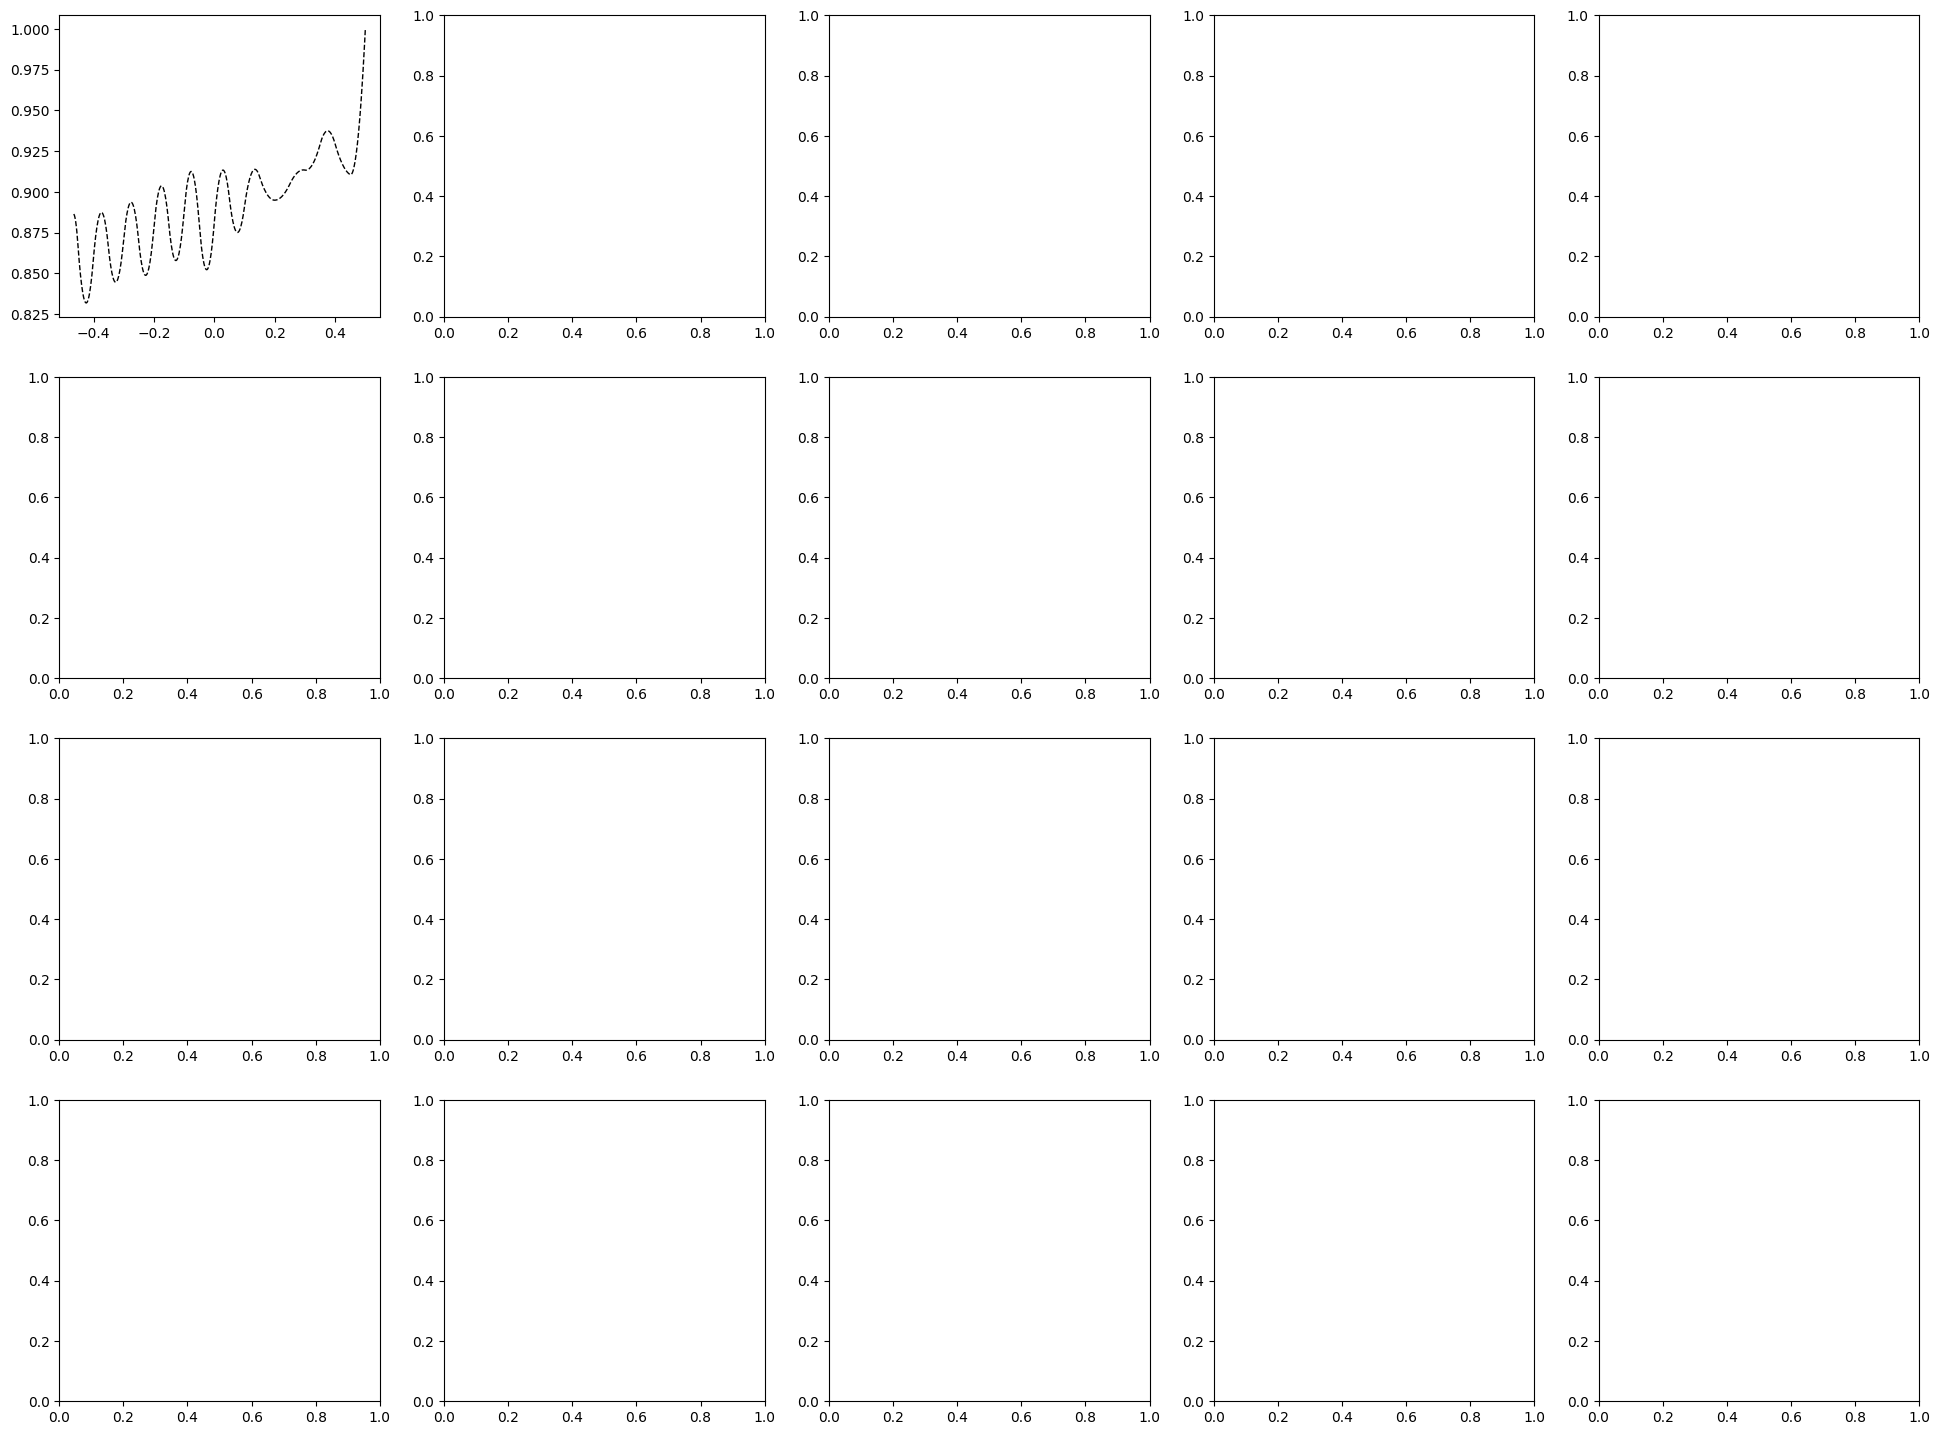

In [ ]:
#import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Converter todas as colunas numéricas dos BLANKs para float
for df in [b1, b2, b3]:
    for col in colunas_disponiveis:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors='coerce'
        )

# Calcular a média dos três BLANKs
b_avg = b1.copy()
for col in colunas_disponiveis:
    b_avg[col] = (b1[col] + b2[col] + b3[col]) / 3

# Criar subplots com tamanho maior
fig, axes = plt.subplots(4, 5, figsize=(24, 18), facecolor="white")
axes = axes.flatten()

for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Plotando os dados normalizados (cada um pelo seu próprio máximo)
    ax.plot(b_avg["V_G"], b_avg[coluna] / b_avg[coluna].max(), color='black', linestyle='--', linewidth=1, label="Branca")
    ax.plot(c10ng["V_G"], c10ng[coluna] / c10ng[coluna].max(), color='red', linestyle='-', linewidth=1,alpha=0.5, label="74 pM")
    ax.plot(c25ng["V_G"], c25ng[coluna] / c25ng[coluna].max(), color='yellow', linestyle='-', linewidth=1, alpha=0.5,label="185 pM")
    ax.plot(c50ng["V_G"], c50ng[coluna] / c50ng[coluna].max(), color='green', linestyle='-', linewidth=1, alpha=0.5,label="370 pM")
    ax.plot(c75ng["V_G"], c75ng[coluna] / c75ng[coluna].max(), color='blue', linestyle='-', linewidth=1, alpha=0.5,label="556 pM")
    ax.plot(c100ng["V_G"], c100ng[coluna] / c100ng[coluna].max(), color='magenta', linestyle='-', linewidth=1, alpha=0.5,label="741 pM")

    # Região de interesse no eixo X
    x_min, x_max = -0.3, 0.3
    ax.set_xlim(x_min, x_max)

    # Ajuste automático do eixo Y entre 0 e 1 (após normalização)
    ax.set_ylim(0, 1.05)

    # Eixos e título
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (normalizado)")
    ax.set_title(f"{coluna}", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação científica removida, pois os valores agora estão entre 0 e 1
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    # Legenda
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


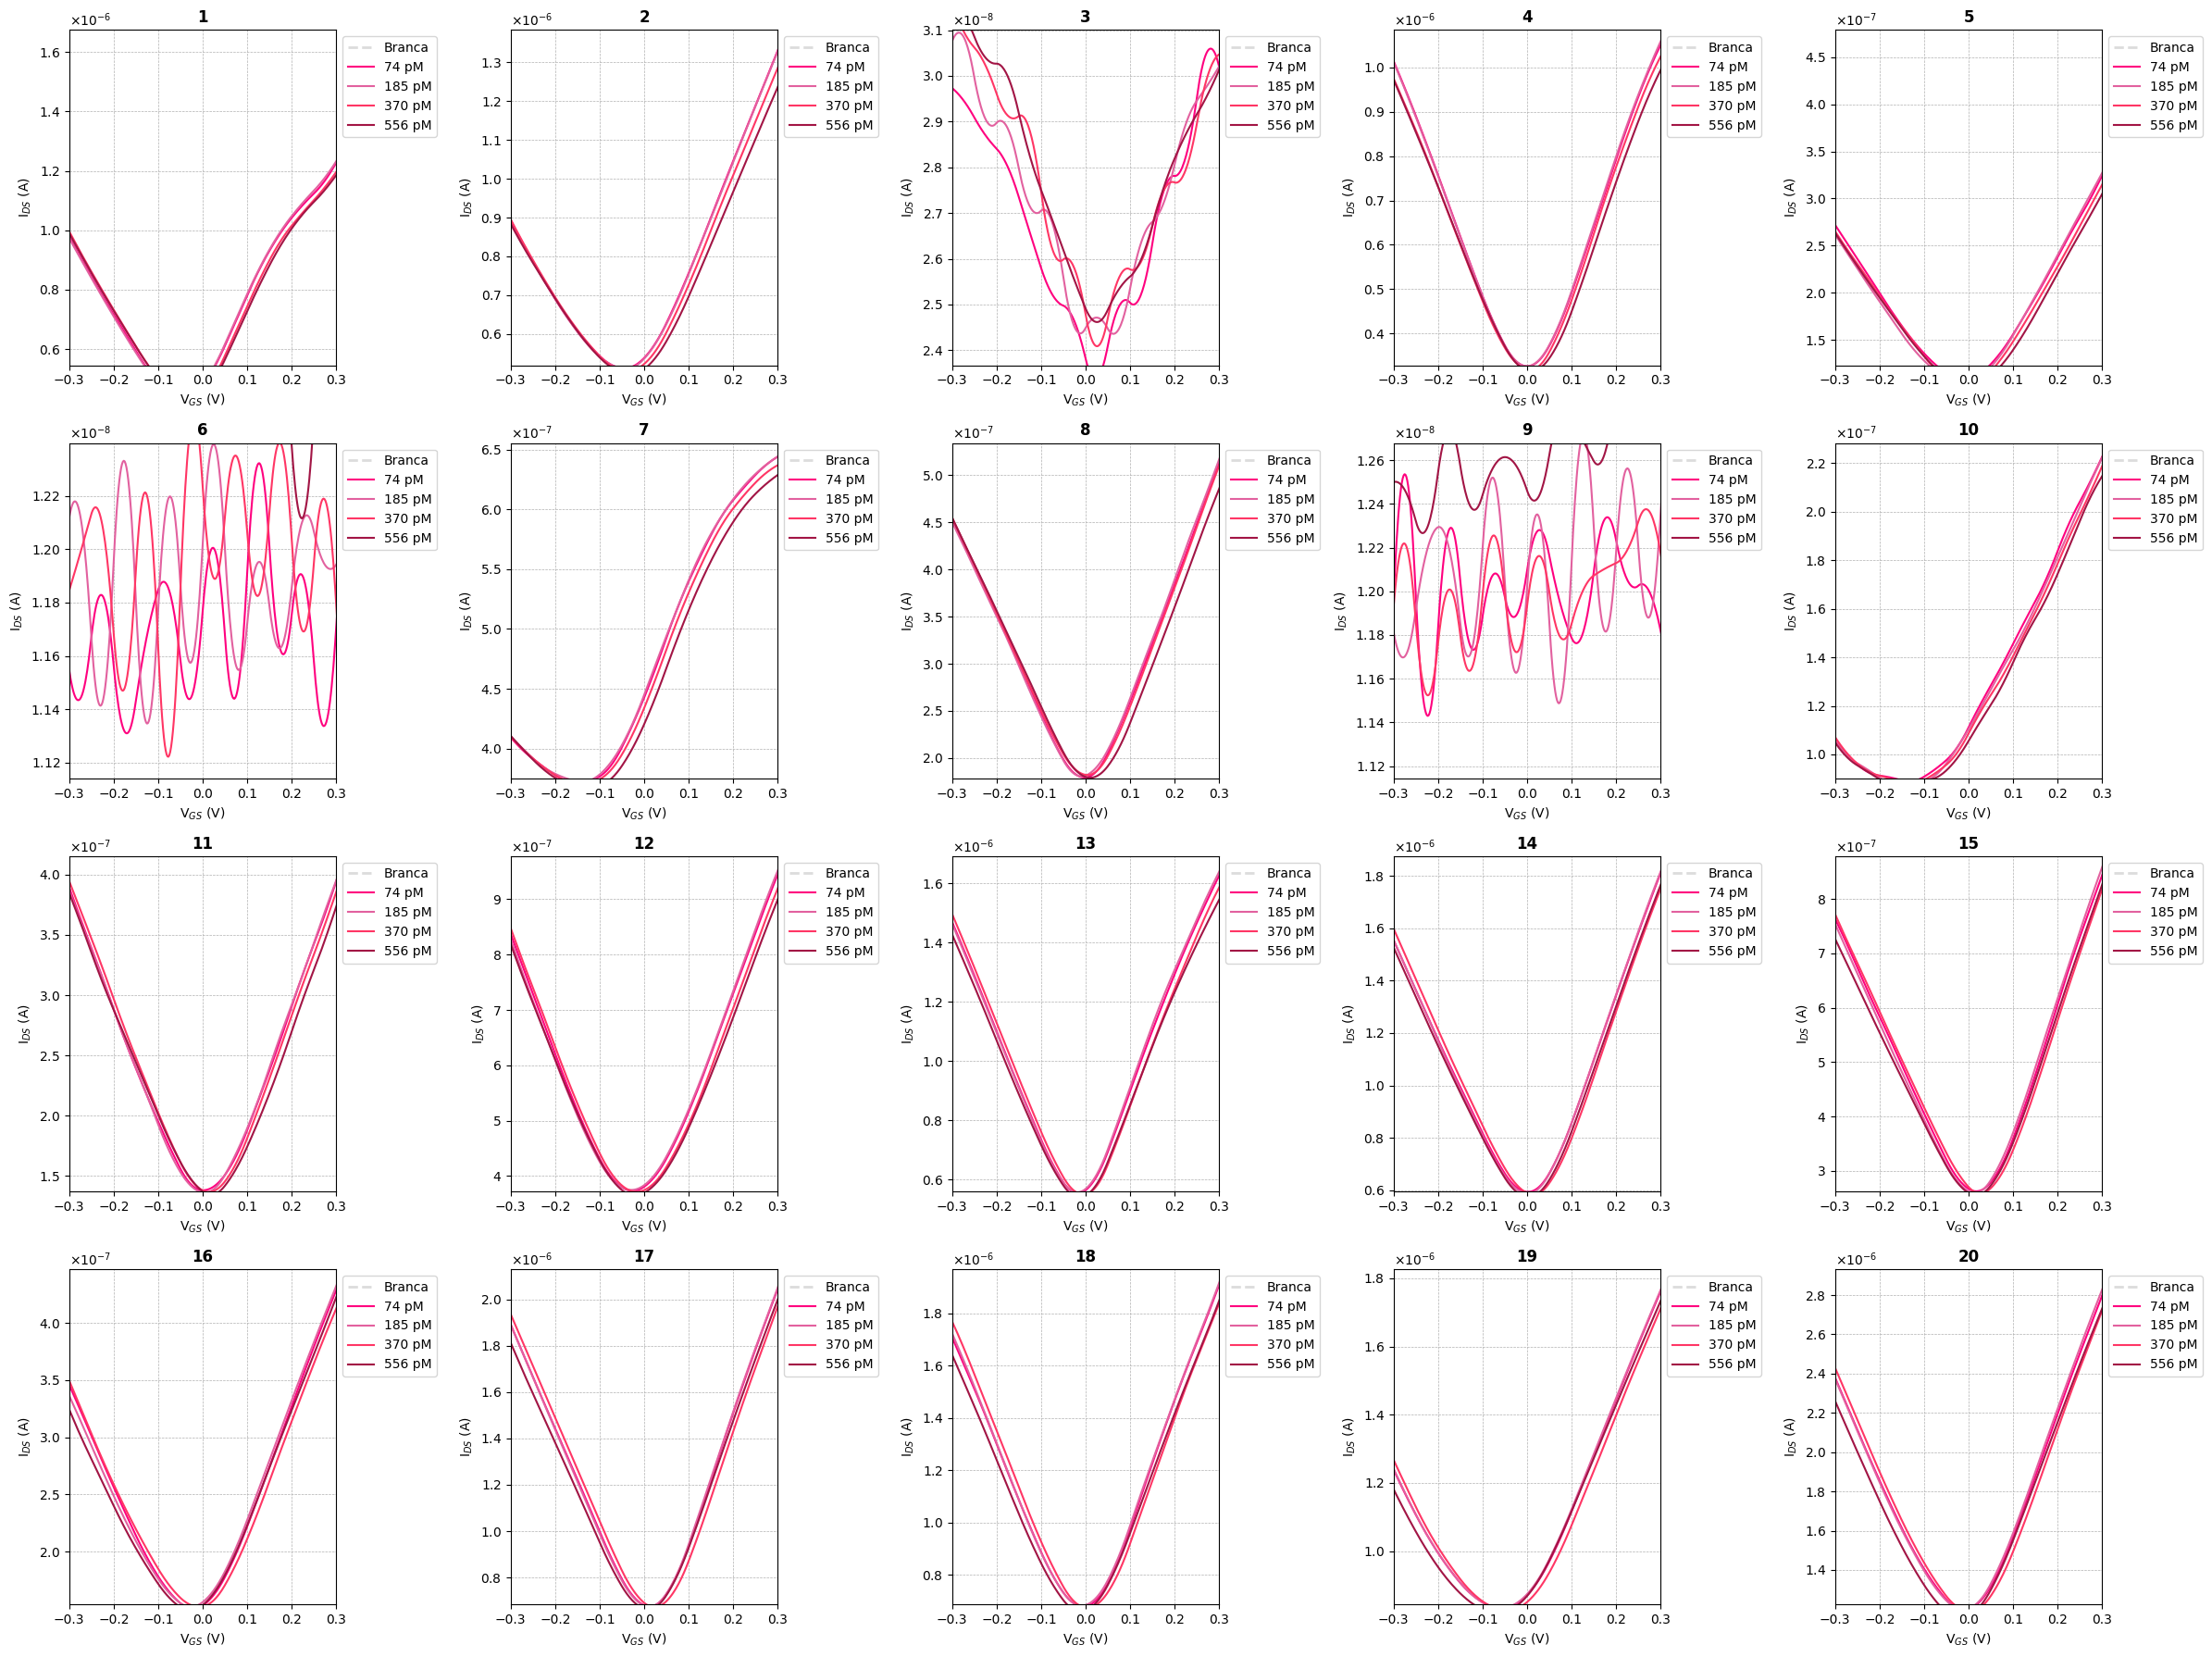

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Converter todas as colunas numéricas dos BLANKs para float
for df in [b1, b2, b3]:
    for col in colunas_disponiveis:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors='coerce'
        )

# Calcular a média dos três BLANKs
b_avg = b1.copy()
for col in colunas_disponiveis:
    b_avg[col] = (b1[col] + b2[col] + b3[col]) / 3

# Criar subplots com tamanho maior
fig, axes = plt.subplots(4, 5, figsize=(24, 18), facecolor="white")
axes = axes.flatten()

for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Plotando os dados
    ax.plot(b_avg["V_G"], b_avg[coluna] / max(b_avg[coluna]), color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(c10ng["V_G"], c10ng[coluna], color='#ff007f', linestyle='-', linewidth=1.5, label="74 pM")
    ax.plot(c25ng["V_G"], c25ng[coluna], color='#e2619f', linestyle='-', linewidth=1.5, label="185 pM")
    ax.plot(c50ng["V_G"], c50ng[coluna], color='#ff3665', linestyle='-', linewidth=1.5, label="370 pM")
    ax.plot(c75ng["V_G"], c75ng[coluna], color='#a21545', linestyle='-', linewidth=1.5, label="556 pM")

    # Selecionar região de interesse
    x_min, x_max = -0.3, 0.3
    mask = (b2["V_G"] >= x_min) & (b2["V_G"] <= x_max)

    # Pegar valores de Y dentro dessa região
    try:
        y_vals = np.concatenate([
            b2.loc[mask, coluna].dropna(),
            menos15.loc[mask, coluna].dropna(),
            menos12.loc[mask, coluna].dropna()
        ])
    except Exception:
        y_vals = np.array([])

    # Ajuste de eixo Y
    if len(y_vals) > 0:
        y_min, y_max = np.min(y_vals), np.max(y_vals)
        if y_min == y_max:
            y_max = y_min * 200
    else:
        y_min, y_max = 1e-15, 1e-8

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Formatação dos eixos
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"{coluna}", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Eixo Y em notação científica
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


In [ ]:
print(colunas_disponiveis)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


Dropdown(description='Device:', index=15, options=('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '1…

FloatText(value=-0.2, description='X min:')

FloatText(value=0.2, description='X max:')

FloatText(value=1e-08, description='Y min:')

FloatText(value=1e-07, description='Y max:')

Button(description='Gerar Gráfico', style=ButtonStyle())

Button(description='Salvar Figura', style=ButtonStyle())

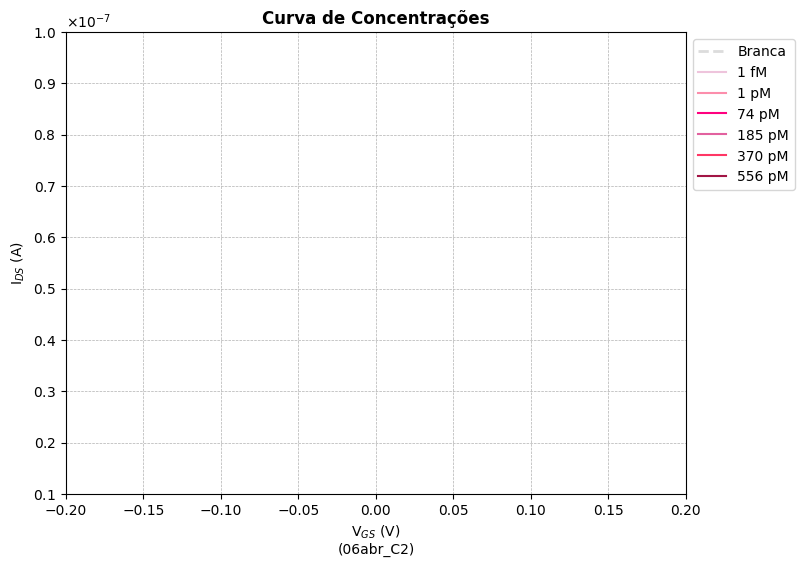

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import ipywidgets as widgets
from IPython.display import display, clear_output
import PIL.Image

# Criando widgets interativos
coluna_selector = widgets.Dropdown(options=colunas_disponiveis, description="Device:")
button_plot = widgets.Button(description="Gerar Gráfico")
button_save = widgets.Button(description="Salvar Figura")

# Widgets para ajuste dos eixos
x_min_input = widgets.FloatText(value=-0.15, description="X min:")
x_max_input = widgets.FloatText(value=0.05, description="X max:")
y_min_input = widgets.FloatText(value=1e-9, description="Y min:")
y_max_input = widgets.FloatText(value=1e-8, description="Y max:")

# Função para gerar o gráfico
def atualizar_grafico(b):
    clear_output(wait=True)
    display(coluna_selector, x_min_input, x_max_input, y_min_input, y_max_input, button_plot, button_save)

    coluna = coluna_selector.value  # Obtém a coluna selecionada

    if not coluna:
        print("Selecione uma coluna válida.")
        return

    # Criar figura
    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

    # Plotando os dados selecionados
    ax.plot(b_avg["V_G"], b_avg[coluna_selector.value]/max(b_avg[coluna_selector.value]), color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(menos15["V_G"], menos15[coluna], color='#eec4dc', linestyle='-', linewidth=1.5, label="1 fM")
    ax.plot(menos12["V_G"], menos12[coluna], color='#fc8eac', linestyle='-', linewidth=1.5, label="1 pM")
    ax.plot(c74pico["V_G"], c74pico[coluna], color='#ff007f', linestyle='-', linewidth=1.5, label="74 pM")
    ax.plot(c185pico["V_G"], c185pico[coluna], color='#e2619f', linestyle='-', linewidth=1.5, label="185 pM")
    ax.plot(c50ng["V_G"], c50ng[coluna], color='#ff3665', linestyle='-', linewidth=1.5, label="370 pM")
    ax.plot(c75ng["V_G"], c75ng[coluna], color='#a21545', linestyle='-', linewidth=1.5, label="556 pM")

    # Ajuste de limites dos eixos com widgets
    x_min, x_max = x_min_input.value, x_max_input.value
    y_min, y_max = y_min_input.value, y_max_input.value

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Formatação dos eixos
    ax.set_xlabel(f"V$_{{GS}}$ (V)\n({CHIP})")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"Curva de Concentrações", fontsize=12, fontweight='bold')
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Formatação científica do eixo Y
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

    # Legenda fora do gráfico
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Atualizar figura global
    global fig_to_save
    fig_to_save = fig  # Armazena para salvamento posterior
    plt.show()

# Função para salvar e abrir a figura
def salvar_e_abrir_figura(b):
    if 'fig_to_save' in globals():  # Verifica se a figura já foi gerada
        caminho = "/content/grafico_temp.png"
        fig_to_save.savefig(caminho, dpi=400, bbox_inches='tight')
        print(f"Figura salva temporariamente: {caminho}")

        # Abrindo a imagem
        img = PIL.Image.open(caminho)
        display(img)
    else:
        print("Gere o gráfico antes de salvar.")

# Associar as funções aos botões
button_plot.on_click(atualizar_grafico)
button_save.on_click(salvar_e_abrir_figura)

# Exibir widgets
display(coluna_selector, x_min_input, x_max_input, y_min_input, y_max_input, button_plot, button_save)


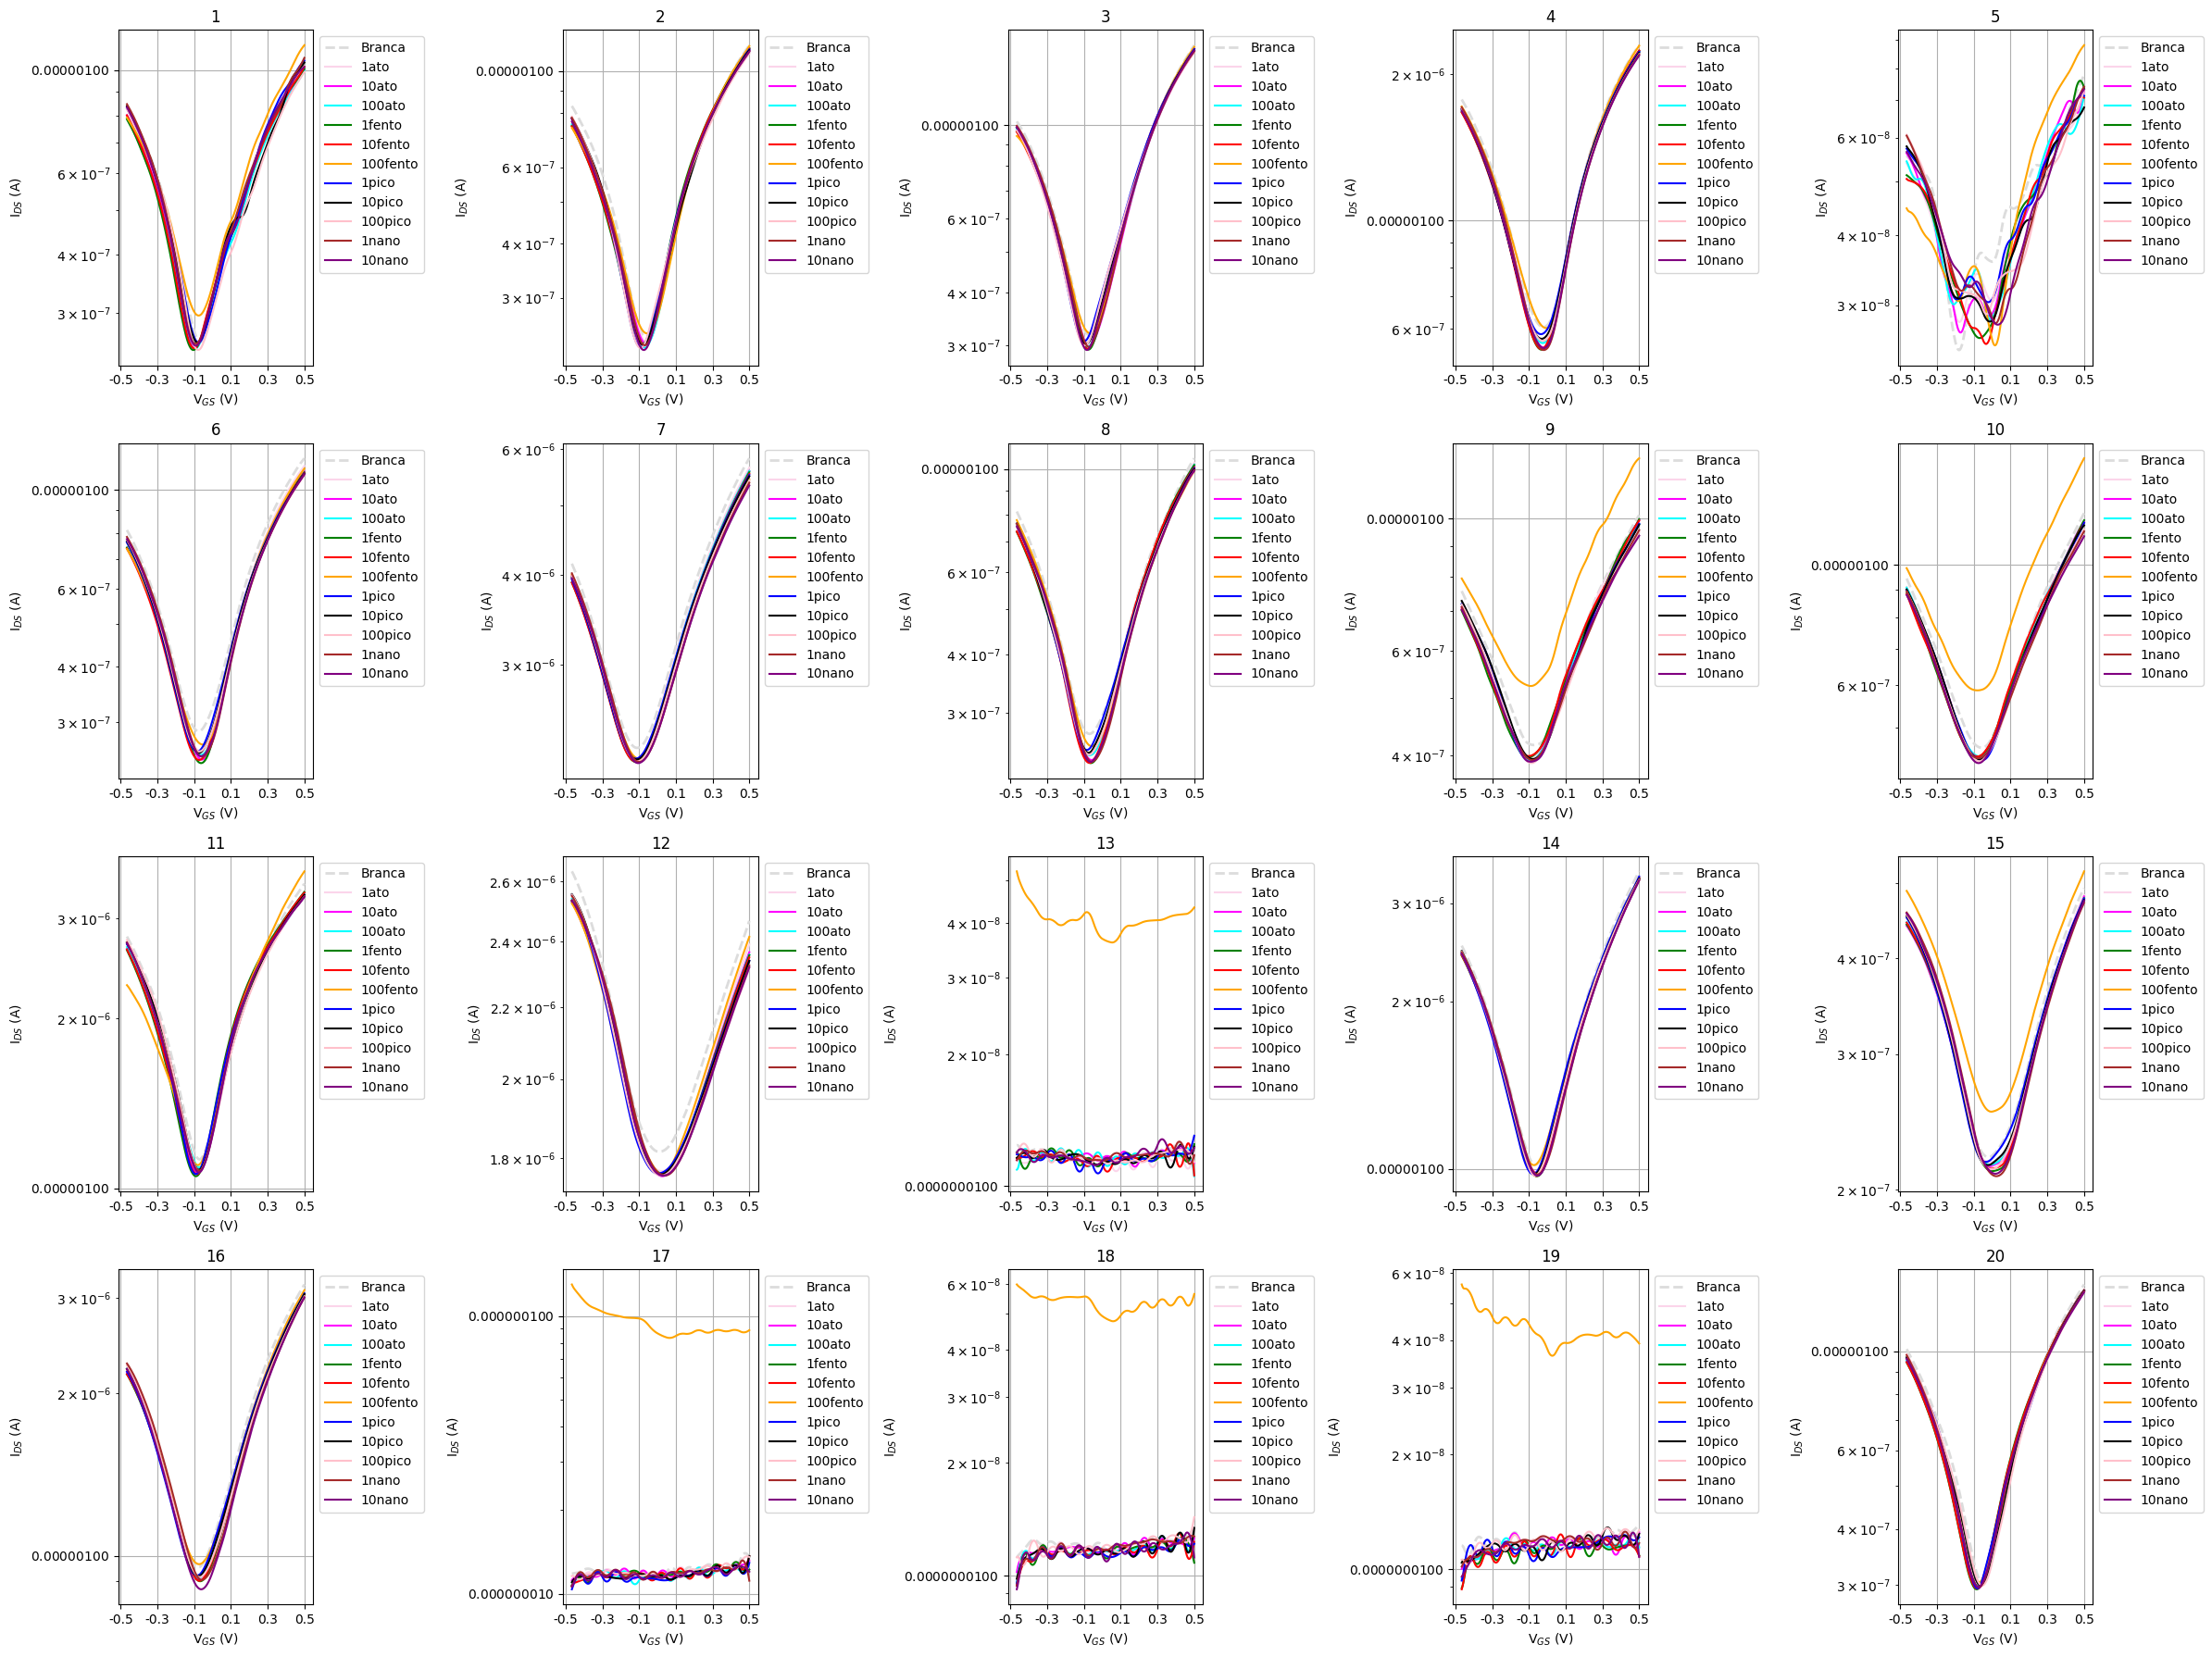

'\n# Salvar todas as figuras\nfor idx, coluna in enumerate(colunas_disponiveis):\n    caminho = f"{pasta_resultados}/Curva_Proteinas_{CHIP}_{coluna}.png"\n    fig.savefig(caminho, dpi=400, bbox_inches=\'tight\')\n    print(f"Figura salva em: {caminho}")\n'

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Criar subplots com tamanho maior
fig, axes = plt.subplots(4, 5, figsize=(24, 18), facecolor="white")
axes = axes.flatten()

for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Plot com linhas mais espessas para melhor visualização
    ax.plot(b2["V_G"], b2[coluna], color='#DCDCDC', linestyle='--', linewidth=2, label="Branca")
    ax.plot(menos18["V_G"], menos18[coluna], color='#FBD5EA', linestyle='-', linewidth=1.5, label="1ato")
    ax.plot(menos17["V_G"], menos17[coluna], color='magenta', linestyle='-', linewidth=1.5, label="10ato")
    ax.plot(menos16["V_G"], menos16[coluna], color='cyan', linestyle='-', linewidth=1.5, label="100ato")
    ax.plot(menos15["V_G"], menos15[coluna], color='green', linestyle='-', linewidth=1.5, label="1fento")
    ax.plot(menos14["V_G"], menos14[coluna], color='red', linestyle='-', linewidth=1.5, label="10fento")
    ax.plot(menos13["V_G"], menos13[coluna], color='orange', linestyle='-', linewidth=1.5, label="100fento")
    ax.plot(menos12["V_G"], menos12[coluna], color='blue', linestyle='-', linewidth=1.5, label="1pico")
    ax.plot(menos11["V_G"], menos11[coluna], color='black', linestyle='-', linewidth=1.5, label="10pico")
    ax.plot(menos10["V_G"], menos10[coluna], color='pink', linestyle='-', linewidth=1.5, label="100pico")
    ax.plot(menos9["V_G"], menos9[coluna], color='brown', linestyle='-', linewidth=1.5, label="1nano")
    ax.plot(menos8["V_G"], menos8[coluna], color='purple', linestyle='-', linewidth=1.5, label="10nano")

    # Ajuste de eixos
    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (A)")
    ax.set_title(f"{coluna}")
    ax.set_yscale("log")
    ax.grid(True)

    # Formatação dos ticks
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)

    # Ticks no eixo X
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(x) for x in x_ticks])

    # Mover legenda para fora do gráfico
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

"""
# Salvar todas as figuras
for idx, coluna in enumerate(colunas_disponiveis):
    caminho = f"{pasta_resultados}/Curva_Proteinas_{CHIP}_{coluna}.png"
    fig.savefig(caminho, dpi=400, bbox_inches='tight')
    print(f"Figura salva em: {caminho}")
"""

In [ ]:
# Criando um DataFrame com a média dos três BLANKs
b_avg = b1.copy()
b_avg[coluna_selector.value] = (b1[coluna_selector.value] + b2[coluna_selector.value] + b3[coluna_selector.value]) / 3

# Lista de opções para o eixo Y
colunas_disponiveis = list(bare.columns)
colunas_disponiveis.remove("V_G")

# Criar subplots para visualizar todos os gráficos
fig, axes = plt.subplots(4, 5, figsize=(20, 16), facecolor="white")  # 4 linhas, 5 colunas
axes = axes.flatten()

# Gerar gráficos para cada coluna disponível
for idx, coluna in enumerate(colunas_disponiveis):
    ax = axes[idx]

    # Garantir que os valores de V_G são numéricos
    b_avg["V_G"] = b_avg["V_G"].astype(str).str.replace(",", ".").astype(float)

    # Definir os valores do eixo X arredondados
    x_min, x_max = round(b_avg["V_G"].min(), 1), round(b_avg["V_G"].max(), 1)
    x_ticks = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]
    x_ticks = [x for x in x_ticks if x_min <= x <= x_max]

    # Definir os valores do eixo Y (0.2, 0.4, 0.6, 0.8, 1 µA)
    y_ticks_micro = np.array([0.2, 0.4, 0.6, 0.8, 1])
    y_ticks = y_ticks_micro * 1e-6

    # Aplicar os ticks no eixo Y
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(y) for y in y_ticks_micro])

    # Usar ScalarFormatter para evitar notação científica
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)

    # Plot das curvas
    ax.plot(b_avg["V_G"], b_avg[coluna] / max(b_avg[coluna]), color='#DCDCDC', linestyle='--', linewidth=1, label="Branca (média)")
    ax.plot(menos18["V_G"], menos18[coluna], color='#FBD5EA', linestyle='-', label="1ato")
    ax.plot(menos17["V_G"], menos17[coluna], color='magenta', linestyle='-', label="10ato")
    ax.plot(menos16["V_G"], menos16[coluna], color='magenta', linestyle='-', label="100ato")
    ax.plot(menos15["V_G"], menos15[coluna], color='magenta', linestyle='-', label="1fento")
    ax.plot(menos14["V_G"], menos14[coluna], color='magenta', linestyle='-', label="10fento")

    ax.set_xlabel("V$_{GS}$ (V)")
    ax.set_ylabel("I$_{DS}$ (µA)")
    ax.set_title(f"{coluna}")  # Nome da coluna no título
    ax.set_yscale("log")
    ax.grid(False)

    # Ajustar os rótulos do eixo X
    ax.set_xticks(x_ticks)

plt.tight_layout()
plt.show()

"""
# Salvar todas as figuras
for idx, coluna in enumerate(colunas_disponiveis):
    caminho = f"{pasta_resultados}/Curva_Proteina_{CHIP}_{coluna}.png"
    fig.savefig(caminho, dpi=400, bbox_inches='tight')
    print(f"Figura salva em: {caminho}")
"""

NameError: name 'coluna_selector' is not defined

EU QUERIA COLOCAR SEM A NOTAÇÃO CIENTÍFICA, COMO NESSE AQUI 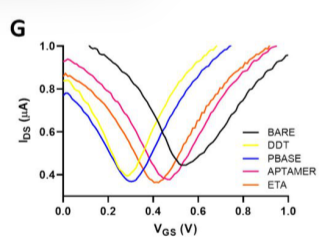

# **ANOTANDO OS DEVICES BONS**

---------03 abril ---------
C1 = 6  20  13   19
C2 = 10